# RSA analysis for the brain binding roject


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import datetime

import nibabel as nib
import nilearn as nl
import glob
from nilearn import plotting, glm


In [1]:
data_dir    = '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/' 
results_dir = "rsa_results"

sub_dirs = ['sub-{:03d}'.format(i) for i in [2, 8]]
print(sub_dirs)

['sub-002', 'sub-008']


Repeat what Grace did to know what's going on and how to get handles on the data

In [4]:
# make binary masks from fMRIprep outputted probability maps 

threshold = 0.4 # you can try out different thresholds, generally between .2 - .5

subject_masks = [data_dir+sub+'/ses-01/anat/'+sub+'_ses-01_space-MNI152NLin2009cAsym_res-2_label-GM_probseg.nii.gz' for sub in sub_dirs]

binary_subject_masks = [nib.Nifti1Image(
       (nib.load(p).get_fdata() > threshold).astype(np.uint8),
        nib.load(p).affine,
        nib.load(p).header
    )
    for p in subject_masks
] 

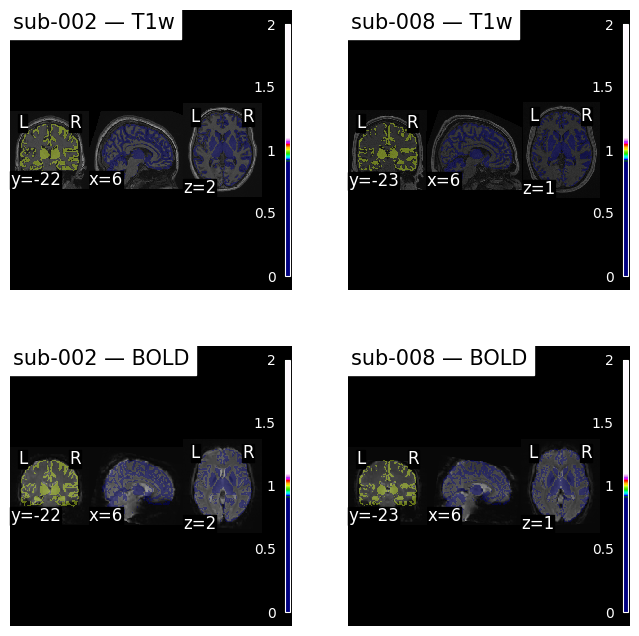

In [6]:
# make figure with 2 rows (anat, func) and N columns (subjects)
n_subs = len(sub_dirs)
fig, axes = plt.subplots(2, n_subs, figsize=(4 * n_subs, 8))

# edge case: if only one subject
if n_subs == 1:
    axes = axes.reshape(2, 1)

boldref_path_list = ['/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/sub-002_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/func/sub-008_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz'] #My code: create a list for the boldref_paths (to be used below).

for idx,(mask,sub) in enumerate(zip(binary_subject_masks,sub_dirs)):
    anat_path = data_dir+sub+'/ses-01/anat/'+sub+'_ses-01_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz'
    anat_img = nib.load(anat_path)

    boldref_path = boldref_path_list[0] #boldref_path = data_dir+sub+'/ses-01/func/'+sub+'_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz'
    boldref_path_list.pop(0) #My code: remove the first path from the boldref_path_list in order to move to the next path on the next iteration.
    #print(boldref_path_list) #My code: check the boldref_path_list to make sure that the first element is being removed with the previous line.
    boldref_4d = nib.load(boldref_path)
    boldref_img = boldref_4d.slicer[..., 0]   

    # show the mask overlaid on anatomical
    display_anat = plotting.plot_roi(mask,bg_img=anat_img,alpha=0.4,display_mode="ortho",draw_cross=False,axes=axes[0, idx],title=f"{sub} — T1w",figure=fig)
    
    # show the mask overlaid on functional
    display_func = plotting.plot_roi(mask,bg_img=boldref_img,alpha=0.4,display_mode="ortho",draw_cross=False,axes=axes[1, idx],title=f"{sub} — BOLD",figure=fig)

#plt.tight_layout()
plt.show()

In [16]:
# events files for all subjects
events_files = ['/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-02_16-25-49/7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99.csv',
                '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-04_18-13-59/e3f4c2c2-e078-42a1-970c-cc7833d2a7b2.csv']

events_dfs = [pd.read_csv(f) for f in events_files]

In [6]:
def get_good_runs(data_dir, subject, df_path, percent_frames=.30, fwd=.5, exclude=[]): #My note: I included a parameter for df_path (since our file paths differ).
    '''
    input   :  data_dir  - string - path to subject directories
               subject   - string - subject directory
    output  :  good_runs - list   - list of runs with <30% of frames with motion (>=.5 FWD)
    '''
    
    good_runs   = []
    regressors  = []
    
    for r in ['1']: #My note: I changed this from 01 to 1 to match our file paths.    #['01','02','03','04','05','06']:
        
        if r not in exclude:
        
            df      = pd.read_csv(data_dir + '/' + df_path, sep="\t") #I replaced the data_dir+subject+'/ses-01/func/'+subject+'_ses-01_task-perceptXbind_run-'+r+'_desc-confounds_timeseries.tsv' path with df_path.
            percent = df[df['framewise_displacement']>=fwd].shape[0] / df.shape[0]

            # if bad motion in less than 30% of frames --> good run
            if percent < percent_frames:
                good_runs.append(r)

                l = list(df['framewise_displacement']>=fwd)
                l_new = [int(x) for x in l]
                regressors.append(l_new)

    print(good_runs)
    print(regressors)
    return(good_runs,regressors)

In [7]:
data_dirs = [data_dir+sub+'/ses-01/func/' for sub in sub_dirs]
print(data_dirs)
df_paths = ['sub-002_ses-01_task-perceptXbind_run-1_desc-confounds_timeseries.tsv', 'sub-008_ses-01_task-perceptXbind_run-1_desc-confounds_timeseries.tsv'] #My code: create a list for the df_paths (to be used below).

for data_dir, sub, df_path in zip(data_dirs, sub_dirs, df_paths): #My code: loop through the data_dirs, sub_dirs, and df_paths together using zip.
    print(f"Subject: {sub}")
    get_good_runs(data_dir, sub, df_path) #My code: pass the df_path to the get_good_runs function.

['/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/', '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/func/']
Subject: sub-002
['1']
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [4]:
boldref_path_list = ['/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/sub-002_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
                '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/func/sub-008_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz'] #My code: create a list for the boldref_paths (to be used below).
contrast = 'ABA - ABB'
events_files_with_onset_column = ['/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-02_16-25-49/7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99_with_t_fixation_renamed_to_onset.csv',
                '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-04_18-13-59/e3f4c2c2-e078-42a1-970c-cc7833d2a7b2_with_t_fixation_renamed_to_onset.csv'] #My code: create a new list of event_files to include an onset column (I replaced the t_fixation label with the onset label). Use this in the for loop below.



In [5]:
# boldref_path_list = ['/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-001/ses-01/func/sub-001_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz', 
#                 '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/sub-002_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
#                 '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/func/sub-008_ses-01_task-perceptX2bind_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz'] #My code: create a list for the boldref_paths (to be used below).

boldref_path_list = ['/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/sub-002_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
                '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/func/sub-008_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz'] #My code: create a list for the boldref_paths (to be used below).
contrast = 'ABA - ABB'
events_files_with_onset_column = ['/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-02_16-25-49/7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99_with_t_fixation_renamed_to_onset.csv',
                '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-04_18-13-59/e3f4c2c2-e078-42a1-970c-cc7833d2a7b2_with_t_fixation_renamed_to_onset.csv'] #My code: create a new list of event_files to include an onset column (I replaced the t_fixation label with the onset label). Use this in the for loop below.

#event = pd.read_csv(events_files_with_onset_column[0])
#print(event['onset'])
for subject,events,mask in zip(sub_dirs,events_files_with_onset_column,binary_subject_masks): #My note: these are all correct for our file paths.
    
    # create model object 
    model = nl.glm.first_level.FirstLevelModel(
                                          t_r=2,
                                          hrf_model='glover',
                                          mask_img=mask,
                                          smoothing_fwhm=4, # 8, 6, 4, 2..? 
                                          standardize='zscore_sample', 
                                          signal_scaling=False,
                                          drift_model=None, # bc we use high-pass filtering from fMRIprep (confounds)
                                          minimize_memory=False)
                                          # high_pass= .01 <-- if we were using drift_model
    
                                          # standardize important, particularly for MVPA
                                          # normalizing across time or space (aka "demeaning")
                                          # more standard to do temporal (default for "True")
                                          # for MVPA --> better to do spatial :)
    
    # get the brain images for the runs you want 
    runs = ['1'] #My note: I changed this from 01 to 1 to be consistent with our file paths.
    image_list = [boldref_path_list[0]] #My code: I changed it to the file paths from our system from [ data_dir+subject+'/ses-01/func/'+subject+'_ses-01_task-PredictingAttention_run-'+x+'_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz' for x in runs ].
    print(image_list)
    boldref_path_list.pop(0) #My code: get rid of the first element in the boldref_path_list by using pop (to make sure that each iteration uses the next path, which corresponds to the next subject).
    full_data = [ nib.load(i) for i in image_list]
    n_frames = full_data[0].shape[-1]  # <- remember each run might have different # of frames 
    print(n_frames)
    mask = nl.image.resample_to_img(mask, full_data[0], interpolation='nearest') 

    # get confounds for those runs (rom fMRIprep)
    strategy   = [ 'motion','wm_csf','global_signal','compcor','scrub','high_pass' ]
    confounds_all  = [ nl.interfaces.fmriprep.load_confounds(x, 
                                                        strategy = strategy, 
                                                        fd_threshold=0.5,
                                                        n_compcor = 5,
                                                        motion ='basic',
                                                        demean = False) for x in image_list ]#[0]
    
    # confounds notes: people may find 'global_signal' controversial..?
    # confounds notes: here, I use motion='basic' which uses 6 motion params; some people/ pipelines might use more, e.g. a 24-parameter model   

    # get "sample masks"; replace any cases of None with an array listing all frames
    sm_list = [x[1] for x in confounds_all]
    sm_list = [np.arange(n_frames) if x is None else x for x in sm_list]

    # make design matrices from event timings
    event_dfs = [ pd.read_csv(events) ]
    design_matrices = []

    for e,c in zip(event_dfs, confounds_all):
        TR_array   = np.array([x*2 for x in np.arange(n_frames)])
        matrix = glm.first_level.make_first_level_design_matrix(TR_array, 
                                                                e, 
                                                                hrf_model='glover', 
                                                                drift_model=None,
                                                                add_regs = c[0])
        design_matrices.append(matrix)
        
    print(len(design_matrices))
    # fit the model
    continue
    print('fitting the model!')
    fitted_model = model.fit(full_data, 
                             design_matrices = design_matrices,
                             sample_masks    = sm_list)

    # compute contrasts
    z_score  = fitted_model.compute_contrast(contrast, output_type='z_score') # for viewing
    eff_size = fitted_model.compute_contrast(contrast, output_type='effect_size') # for analysis

    # make output directory if it doesn't exist
    path_base = 'first_level_GLM'; directory_path = results_dir 
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)

    # save contrasts
    contrast_label = contrast.replace(' ', '-')
    # now = datetime.datetime.now(); date_time = now.strftime('%Y-%m-%d_%H-%M-%S') 
    basename = os.path.splitext(os.path.basename(events))[0]
    z_score.to_filename(os.path.join(directory_path, basename + '_' + contrast_label + '_' + subject +'_z-score.nii.gz'))
    eff_size.to_filename(os.path.join(directory_path, basename + '_' + contrast_label + '_' + subject +'_eff-size.nii.gz'))
    break
    print('contrasts for sub '+ subject +'saved!'); print()

['/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/sub-002_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz']
797


/tmp/ipykernel_2387856/2712000961.py:64: UserWarning: The following unexpected columns in events data will be ignored: response_stim, isi2, t_test1, sample_stim, slot_mapping, rt, isi1, isi3, t_rule1, correct, isi_condition, response_slot, trial, t_delay, test_sequence, A_prime, isi4, B_prime, correct_stim, t_response, isi5, response_key, correct_next_stim, A_stim, iti, B_stim, t_rule3, block, rule_sequence, t_test2, t_rule2, t_sample, sid
  matrix = glm.first_level.make_first_level_design_matrix(TR_array,
/tmp/ipykernel_2387856/2712000961.py:64: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  matrix = glm.first_level.make_first_level_design_matrix(TR_array,


1
['/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/func/sub-008_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz']
775
1


/tmp/ipykernel_2387856/2712000961.py:64: UserWarning: The following unexpected columns in events data will be ignored: response_stim, isi2, t_test1, sample_stim, slot_mapping, rt, isi1, isi3, t_rule1, correct, isi_condition, response_slot, trial, t_delay, test_sequence, A_prime, isi4, B_prime, correct_stim, t_response, isi5, response_key, correct_next_stim, A_stim, iti, B_stim, t_rule3, block, rule_sequence, t_test2, t_rule2, t_sample, sid
  matrix = glm.first_level.make_first_level_design_matrix(TR_array,
/tmp/ipykernel_2387856/2712000961.py:64: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  matrix = glm.first_level.make_first_level_design_matrix(TR_array,


<Axes: label='conditions', ylabel='scan number'>

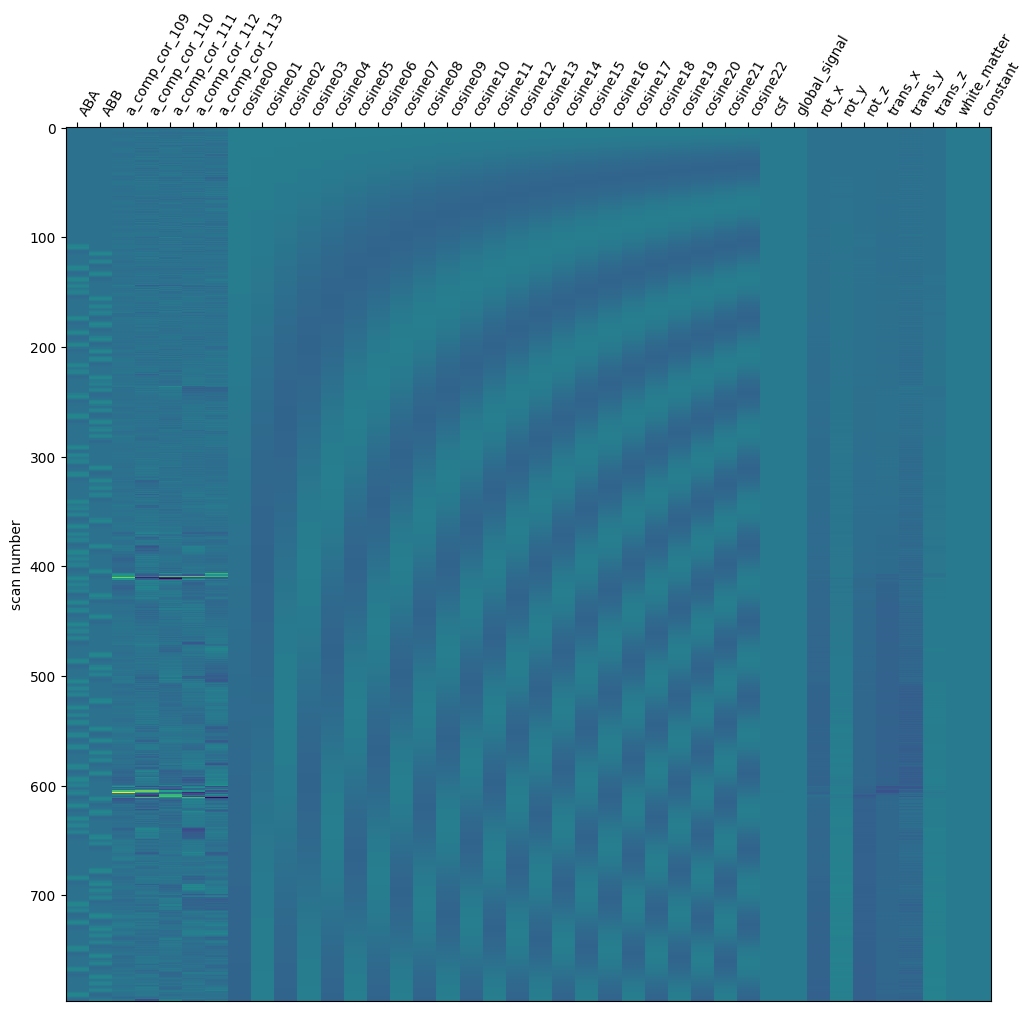

In [12]:
plotting.plot_design_matrix(design_matrices[0])

In [15]:
event_dfs[0]

,block,sid,trial,sample_stim,isi_condition,trial_type,A_stim,B_stim,A_prime,B_prime,...,onset,t_sample,t_delay,t_rule1,t_rule2,t_rule3,t_test1,t_test2,t_response,duration
0,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,0,triangle,1.0,NaN,NaN,NaN,NaN,NaN,...,120.544442,121.064368,121.579318,NaN,NaN,NaN,NaN,NaN,122.612704,2.068262
1,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,1,star,2.5,NaN,NaN,NaN,NaN,NaN,...,123.143501,123.662640,124.178630,NaN,NaN,NaN,NaN,NaN,126.713441,3.569940
2,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,2,rectangle,1.0,NaN,NaN,NaN,NaN,NaN,...,127.262468,127.779267,128.296155,NaN,NaN,NaN,NaN,NaN,129.312179,2.049711
3,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,3,rectangle,2.5,NaN,NaN,NaN,NaN,NaN,...,129.993111,130.512444,131.029092,NaN,NaN,NaN,NaN,NaN,133.545812,3.552701
4,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,4,circle,2.5,NaN,NaN,NaN,NaN,NaN,...,134.392979,134.913506,135.429198,NaN,NaN,NaN,NaN,NaN,137.945691,3.552711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,main_run4,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,115,NaN,NaN,ABB,rectangle,triangle,rectangle,circle,...,1643.647853,NaN,NaN,1644.165795,1645.414853,1646.964339,1648.315249,1649.866174,1651.548324,7.900471
140,main_run4,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,116,NaN,NaN,ABB,star,rectangle,star,triangle,...,1654.116019,NaN,NaN,1654.631534,1655.815157,1657.381713,1659.098501,1660.848905,1662.348662,8.232643
141,main_run4,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,117,NaN,NaN,ABA,circle,triangle,rectangle,triangle,...,1665.831862,NaN,NaN,1666.347808,1667.881652,1669.681030,1671.548589,1672.864219,1674.015176,8.183314
142,main_run4,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,118,NaN,NaN,ABB,circle,star,circle,star,...,1680.065587,NaN,NaN,1680.582131,1682.198637,1683.580953,1685.398516,1687.015817,1688.280926,8.215339


In [9]:
import nibabel as nib
for subject,events,mask in zip(sub_dirs,events_files_with_onset_column,binary_subject_masks): #My note: these are all correct for our file paths.
    basename = os.path.splitext(os.path.basename(events))[0]
    z_img = nib.load(os.path.join(directory_path, basename + '_' + contrast_label + '_'  + subject +'_z-score.nii.gz')) #My code: load the z-score image for each subject using nibabel. I used os.path.join to make sure that the path is correct regardless of the operating system.
    # Glass brain — good for seeing gross activation
    plotting.plot_glass_brain(z_img, 
                            threshold=2.3,    # z > 2.3 ≈ p < .01 uncorrected
                            colorbar=True,
                            title='ABA - ABB (z-score)',
                            display_mode='lyrz')
    plotting.show()

NameError: name 'directory_path' is not defined

# For our thing now!

In [19]:
def get_scan_start_time(log_path):
    """
    Extract time of first scanner TTL pulse from PsychoPy log.
    This is t=0 for the GLM — all onsets must be relative to this.
    """
    with open(log_path, 'r') as f:
        for line in f:
            if 'Keypress: equal' in line:
                return float(line.split('\t')[0])
    raise ValueError(f"No scanner TTL found in {log_path}")


def build_stimulus_events(behavioral_csv_path, log_path, stim_duration=1.0):
    """
    Convert trial-level CSV → stimulus-level events dataframe for nilearn GLM.
    
    Each stimulus presentation becomes one row with:
        onset      : time relative to first TR (seconds)
        duration   : stimulus display duration (seconds)
        trial_type : '{shape}_{role}_{phase}' or '{shape}_{role}_{phase}_{trial_type}'
    
    Parameters
    ----------
    behavioral_csv_path : str
    log_path            : str  - PsychoPy .log file for scan start time
    stim_duration       : float - assumed display duration per stimulus (~1s from your design)
    """
    df = pd.read_csv(behavioral_csv_path)
    df_main = df[df['block'].str.startswith('main')].copy()
    
    scan_t0 = get_scan_start_time(log_path)
    print(f"Scan start time (t0): {scan_t0:.3f}s")
    
    rows = []
    
    for _, trial in df_main.iterrows():
        trial_type = trial['trial_type']   # 'ABA' or 'ABB'
        A  = trial['A_stim']
        B  = trial['B_stim']
        Ap = trial['A_prime']
        Bp = trial['B_prime']
        
        # --- Rule phase ---
        # rule3 role is determined by trial_type: A if ABA, B if ABB
        rule_presentations = [
            (trial['t_rule1'],  A,                             'A',      'rule1'),
            (trial['t_rule2'],  B,                             'B',      'rule2'),
            (trial['t_rule3'],  A if trial_type=='ABA' else B,
                                'A' if trial_type=='ABA' else 'B', 'rule3'),
        ]
        for t, shape, role, phase in rule_presentations:
            rows.append({
                'onset':      t - scan_t0,
                'duration':   stim_duration,
                'trial_type': f'{shape}_{role}_{phase}'
            })
        
        # --- Test phase — further split by trial_type ---
        test_presentations = [
            (trial['t_test1'], Ap, 'Aprime', 'test1'),
            (trial['t_test2'], Bp, 'Bprime', 'test2'),
        ]
        for t, shape, role, phase in test_presentations:
            rows.append({
                'onset':      t - scan_t0,
                'duration':   stim_duration,
                'trial_type': f'{shape}_{role}_{phase}_{trial_type}'
            })
    
    events_df = (pd.DataFrame(rows)
                   .sort_values('onset')
                   .reset_index(drop=True))
    
    # Sanity check
    print(f"\nCondition counts:")
    print(events_df['trial_type'].value_counts().sort_index())
    print(f"\nTotal events: {len(events_df)}")
    print(f"Unique conditions: {events_df['trial_type'].nunique()}")
    
    return events_df

In [20]:
bold_paths = {
    'sub-002': '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/sub-002_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
    'sub-008': '/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-008/ses-01/func/sub-008_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz'
}

In [21]:
# Map each subject to their log file path
log_files = {
    'sub-002': '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-02_16-25-49/7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99.log',
    'sub-008': '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-04_18-13-59/e3f4c2c2-e078-42a1-970c-cc7833d2a7b2.log'
}

behavioral_csvs = {
    'sub-002': events_files_with_onset_column[0],
    'sub-008': events_files_with_onset_column[1],
}

beta_imgs = {}   # will store per-subject stacked beta NIfTIs for RSA

for subject, mask in zip(sub_dirs, binary_subject_masks):
    print(f'\n=== {subject} ===')
    
    # --- Build stimulus-level events ---
    events_df = build_stimulus_events(
        behavioral_csv_path = behavioral_csvs[subject],
        log_path            = log_files[subject],
        stim_duration       = 1.0
    )
    
    # --- Load BOLD (no smoothing — critical for RSA) ---
    bold_path = bold_paths[subject]  # your function from earlier
    bold_img  = nib.load(bold_path)
    n_frames  = bold_img.shape[-1]
    print(f"BOLD shape: {bold_img.shape}")
    
    mask = nl.image.resample_to_img(mask, bold_img, interpolation='nearest')
    
    # --- GLM — NOTE: no smoothing for RSA betas ---
    model = nl.glm.first_level.FirstLevelModel(
        t_r             = 2,
        hrf_model       = 'glover',
        mask_img        = mask,
        smoothing_fwhm  = None,          # ← no smoothing for RSA
        standardize     = 'zscore_sample',
        signal_scaling  = False,
        drift_model     = None,
        minimize_memory = False
    )
    
    # --- Confounds ---
    confounds, sample_mask = nl.interfaces.fmriprep.load_confounds(
        bold_path,
        strategy    = ['motion', 'wm_csf', 'global_signal', 'compcor', 'scrub', 'high_pass'],
        fd_threshold = 0.5,
        n_compcor   = 5,
        motion      = 'basic',
        demean      = False
    )
    if sample_mask is None:
        sample_mask = np.arange(n_frames)
    
    # --- Design matrix ---
    TR_array      = np.arange(n_frames) * 2.0
    design_matrix = nl.glm.first_level.make_first_level_design_matrix(
        TR_array,
        events_df,
        hrf_model    = 'glover',
        drift_model  = None,
        add_regs     = confounds
    )
    
    print(f"Design matrix shape: {design_matrix.shape}")
    print(f"Condition columns: {[c for c in design_matrix.columns if not any(x in c for x in ['motion','csf','wm','comp','drift','scrub','cosine','constant'])]}")
    
    # --- Fit ---
    fitted_model = model.fit(
        [bold_img],
        design_matrices = [design_matrix],
        sample_masks    = [sample_mask]
    )
    
    # --- Extract one beta map per condition ---
    conditions = events_df['trial_type'].unique()
    
    per_condition_betas = []
    for cond in sorted(conditions):
        beta_map = fitted_model.compute_contrast(
            cond,
            output_type = 'effect_size'   # raw beta — not z-score — for RSA
        )
        per_condition_betas.append(beta_map)
    
    # Stack → 4D: (x, y, z, n_conditions)
    beta_4d = nl.image.concat_imgs(per_condition_betas)
    beta_imgs[subject] = (beta_4d, sorted(conditions))
    
    # Save
    beta_4d.to_filename(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))
    pd.Series(sorted(conditions)).to_csv(
        os.path.join(results_dir, f'{subject}_condition_labels.csv'), index=False
    )
    print(f"Saved beta_4d shape: {beta_4d.shape}")


=== sub-002 ===
Scan start time (t0): 120.525s

Condition counts:
trial_type
circle_A_rule1                30
circle_A_rule3                15
circle_Aprime_test1_ABA       10
circle_Aprime_test1_ABB       20
circle_B_rule2                30
circle_B_rule3                15
circle_Bprime_test2_ABA       15
circle_Bprime_test2_ABB       17
rectangle_A_rule1             30
rectangle_A_rule3             15
rectangle_Aprime_test1_ABA    18
rectangle_Aprime_test1_ABB    11
rectangle_B_rule2             30
rectangle_B_rule3             15
rectangle_Bprime_test2_ABA    16
rectangle_Bprime_test2_ABB    17
star_A_rule1                  30
star_A_rule3                  15
star_Aprime_test1_ABA         15
star_Aprime_test1_ABB         18
star_B_rule2                  30
star_B_rule3                  15
star_Bprime_test2_ABA         13
star_Bprime_test2_ABB         12
triangle_A_rule1              30
triangle_A_rule3              15
triangle_Aprime_test1_ABA     17
triangle_Aprime_test1_ABB     1

/tmp/ipykernel_2387856/305312835.py:70: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  fitted_model = model.fit(


Saved beta_4d shape: (97, 115, 97, 32)

=== sub-008 ===
Scan start time (t0): 133.358s

Condition counts:
trial_type
circle_A_rule1                30
circle_A_rule3                15
circle_Aprime_test1_ABA       21
circle_Aprime_test1_ABB       15
circle_B_rule2                30
circle_B_rule3                15
circle_Bprime_test2_ABA       13
circle_Bprime_test2_ABB       13
rectangle_A_rule1             30
rectangle_A_rule3             15
rectangle_Aprime_test1_ABA    16
rectangle_Aprime_test1_ABB    14
rectangle_B_rule2             30
rectangle_B_rule3             15
rectangle_Bprime_test2_ABA    15
rectangle_Bprime_test2_ABB    21
star_A_rule1                  30
star_A_rule3                  15
star_Aprime_test1_ABA         13
star_Aprime_test1_ABB         16
star_B_rule2                  30
star_B_rule3                  15
star_Bprime_test2_ABA         17
star_Bprime_test2_ABB         16
triangle_A_rule1              30
triangle_A_rule3              15
triangle_Aprime_test1_ABA

/tmp/ipykernel_2387856/305312835.py:70: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  fitted_model = model.fit(


Saved beta_4d shape: (97, 115, 97, 32)


<Axes: label='conditions', ylabel='scan number'>

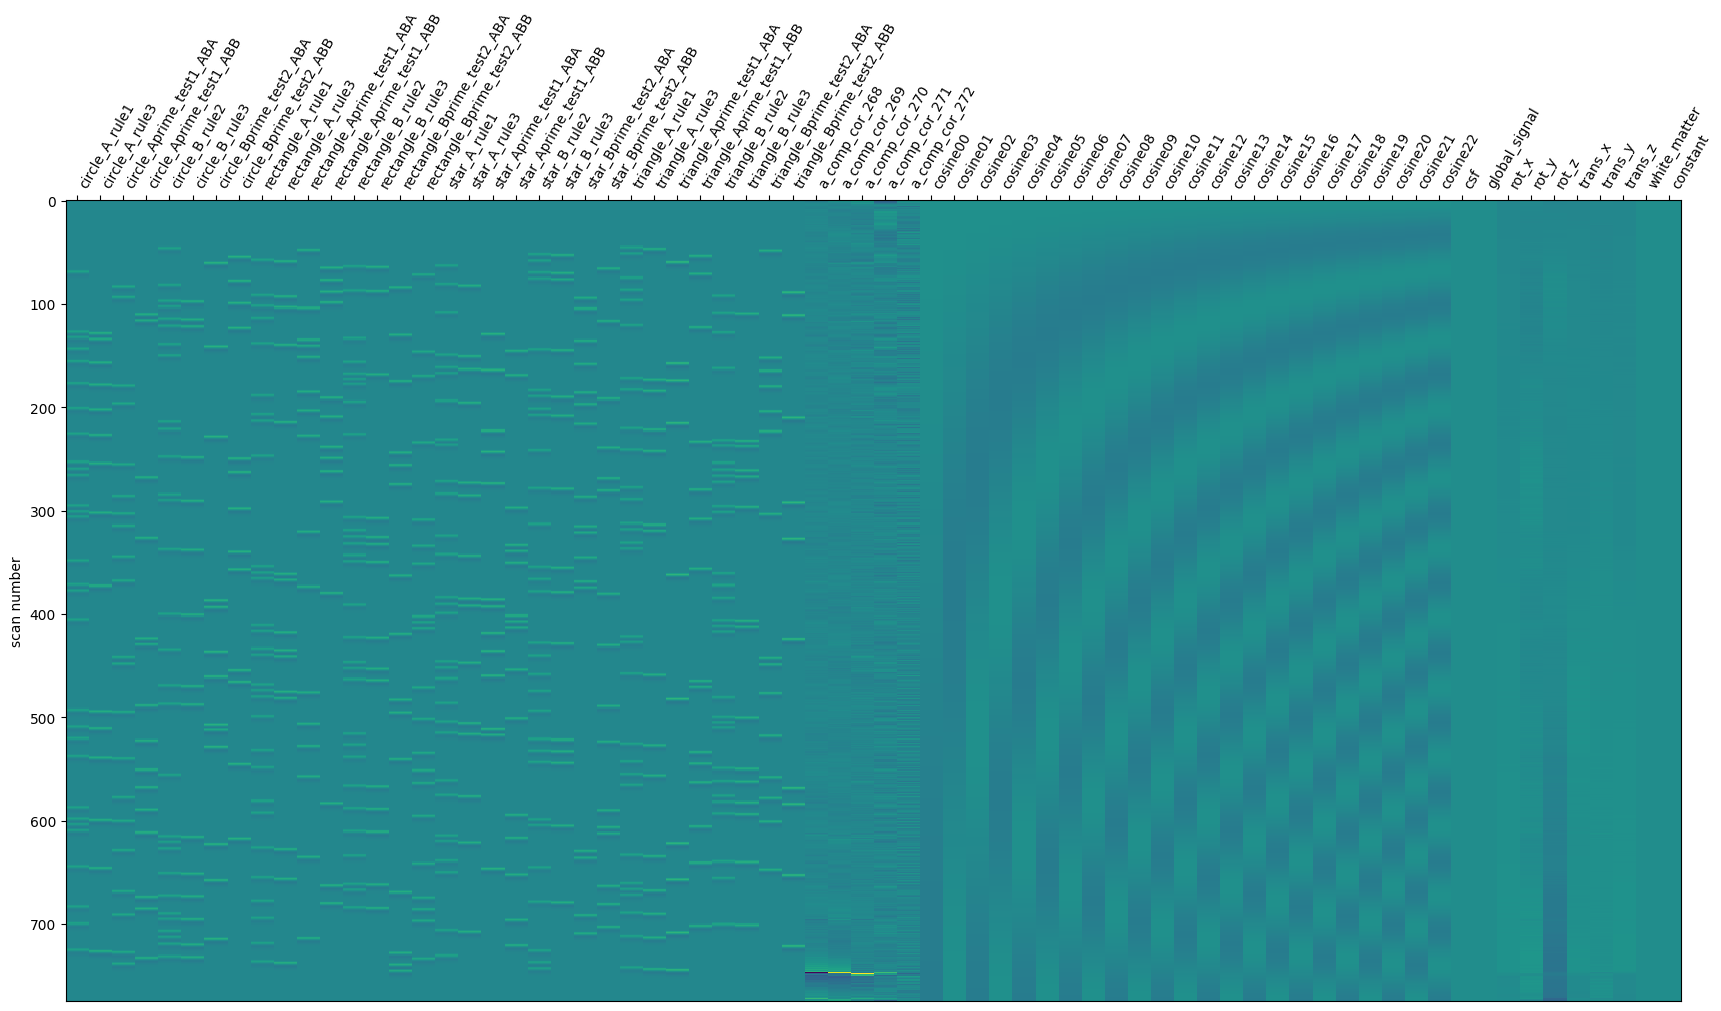

In [22]:
plotting.plot_design_matrix(design_matrix)

In [23]:
# Check the actual onset time difference between test1 and test2
events_df = pd.read_csv(behavioral_csvs['sub-002'])
df_main   = events_df[events_df['block'].str.startswith('main')]

# Compute test2 - test1 onset difference per trial
dt = df_main['t_test2'] - df_main['t_test1']
print(f"test2 - test1 gap: mean={dt.mean():.2f}s, std={dt.std():.2f}s")

# Check correlation between abstract role regressor and position regressor
# in the actual design matrix
dm = design_matrices[0]
aprime_cols = [c for c in dm.columns if 'Aprime' in c]
bprime_cols = [c for c in dm.columns if 'Bprime' in c]

aprime_signal = dm[aprime_cols].sum(axis=1)
bprime_signal = dm[bprime_cols].sum(axis=1)

from scipy.stats import pearsonr
r, p = pearsonr(aprime_signal, bprime_signal)
print(f"Aprime vs Bprime regressor correlation: r={r:.3f}, p={p:.4f}")
# Expect strongly negative — they're anti-correlated by timing

test2 - test1 gap: mean=1.54s, std=0.20s
Aprime vs Bprime regressor correlation: r=nan, p=nan


/tmp/ipykernel_2387856/1150829931.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(aprime_signal, bprime_signal)


In [26]:
bprime_signal.sum()

np.float64(0.0)

In [18]:
conditions = events_df['trial_type'].unique()
n_cond = len(conditions)
print(n_cond)


NameError: name 'events_df' is not defined

In [14]:
def parse_condition(label):
    parts = label.split('_')
    return {
        'shape':     parts[0],
        'role':      parts[1],
        'phase':     parts[2],                          # rule1/rule2/rule3/test1/test2
        'rule_type': parts[3] if len(parts) == 4 else None,
        'epoch':     'rule' if parts[2].startswith('rule') else 'test'
    }

meta = pd.DataFrame([parse_condition(c) for c in conditions], index=conditions)

SHAPES = ['circle', 'rectangle', 'star', 'triangle']
ROLES  = ['A', 'B', 'Aprime', 'Bprime']
PHASES = ['rule1', 'rule2', 'rule3', 'test1', 'test2']
RULES  = ['ABA', 'ABB']

print(meta)
def make_rdm(conditions, sim_fn):
    """
    sim_fn(meta_i, meta_j) -> float in [0, 1]  (1 = identical, 0 = maximally different)
    Returns dissimilarity matrix (1 - similarity).
    """
    n = len(conditions)
    rdm = np.zeros((n, n))
    for i, ci in enumerate(conditions):
        for j, cj in enumerate(conditions):
            rdm[i, j] = 1.0 - sim_fn(meta.loc[ci], meta.loc[cj])
    np.fill_diagonal(rdm, 0)
    return rdm
# M1 — Shape identity
# Similar iff same shape, regardless of role/phase/rule
def sim_shape(a, b):
    return float(a['shape'] == b['shape'])

M1_shape = make_rdm(conditions, sim_shape)

# ─────────────────────────────────────────────────────────────────────────────
# M2 — Abstract role identity (A vs B, collapsing prime distinction)
# A and A' -> same abstract role; B and B' -> same abstract role
def abstract_role(r):
    return 'A' if r in ['A', 'Aprime'] else 'B'

def sim_abstract_role(a, b):
    return float(abstract_role(a['role']) == abstract_role(b['role']))

M2_abstract_role = make_rdm(conditions, sim_abstract_role)

# ─────────────────────────────────────────────────────────────────────────────
# M3 — Concrete role (A, B, Aprime, Bprime fully distinct)
# Tests whether brain tracks exact sequence position
def sim_concrete_role(a, b):
    return float(a['role'] == b['role'])

M3_concrete_role = make_rdm(conditions, sim_concrete_role)

# ─────────────────────────────────────────────────────────────────────────────
# M4 — Epoch (rule phase vs test phase)
# Similar iff both in rule phase or both in test phase
def sim_epoch(a, b):
    return float(a['epoch'] == b['epoch'])

M4_epoch = make_rdm(conditions, sim_epoch)

# ─────────────────────────────────────────────────────────────────────────────
# M5 — Rule type (ABA vs ABB) — only defined for test phase
# Rule phase conditions get a neutral 0.5 similarity to everything
def sim_rule_type(a, b):
    if a['rule_type'] is None or b['rule_type'] is None:
        return 0.5   # rule-phase conditions: uninformative
    return float(a['rule_type'] == b['rule_type'])

M5_rule_type = make_rdm(conditions, sim_rule_type)

# ─────────────────────────────────────────────────────────────────────────────
# M6 — Conjunctive binding: shape AND abstract role
# Tests for bound stimulus-role representations
def sim_binding(a, b):
    same_shape = a['shape'] == b['shape']
    same_role  = abstract_role(a['role']) == abstract_role(b['role'])
    return float(same_shape and same_role)

M6_binding = make_rdm(conditions, sim_binding)


# Collect all
model_rdms = {
    'M1_shape':           M1_shape,
    'M2_abstract_role':   M2_abstract_role,
    'M3_concrete_role':   M3_concrete_role,
    'M4_epoch':           M4_epoch,
    'M5_rule_type':       M5_rule_type,
    'M6_binding':         M6_binding,
}

print("Model RDMs constructed:", list(model_rdms.keys()))

NameError: name 'conditions' is not defined

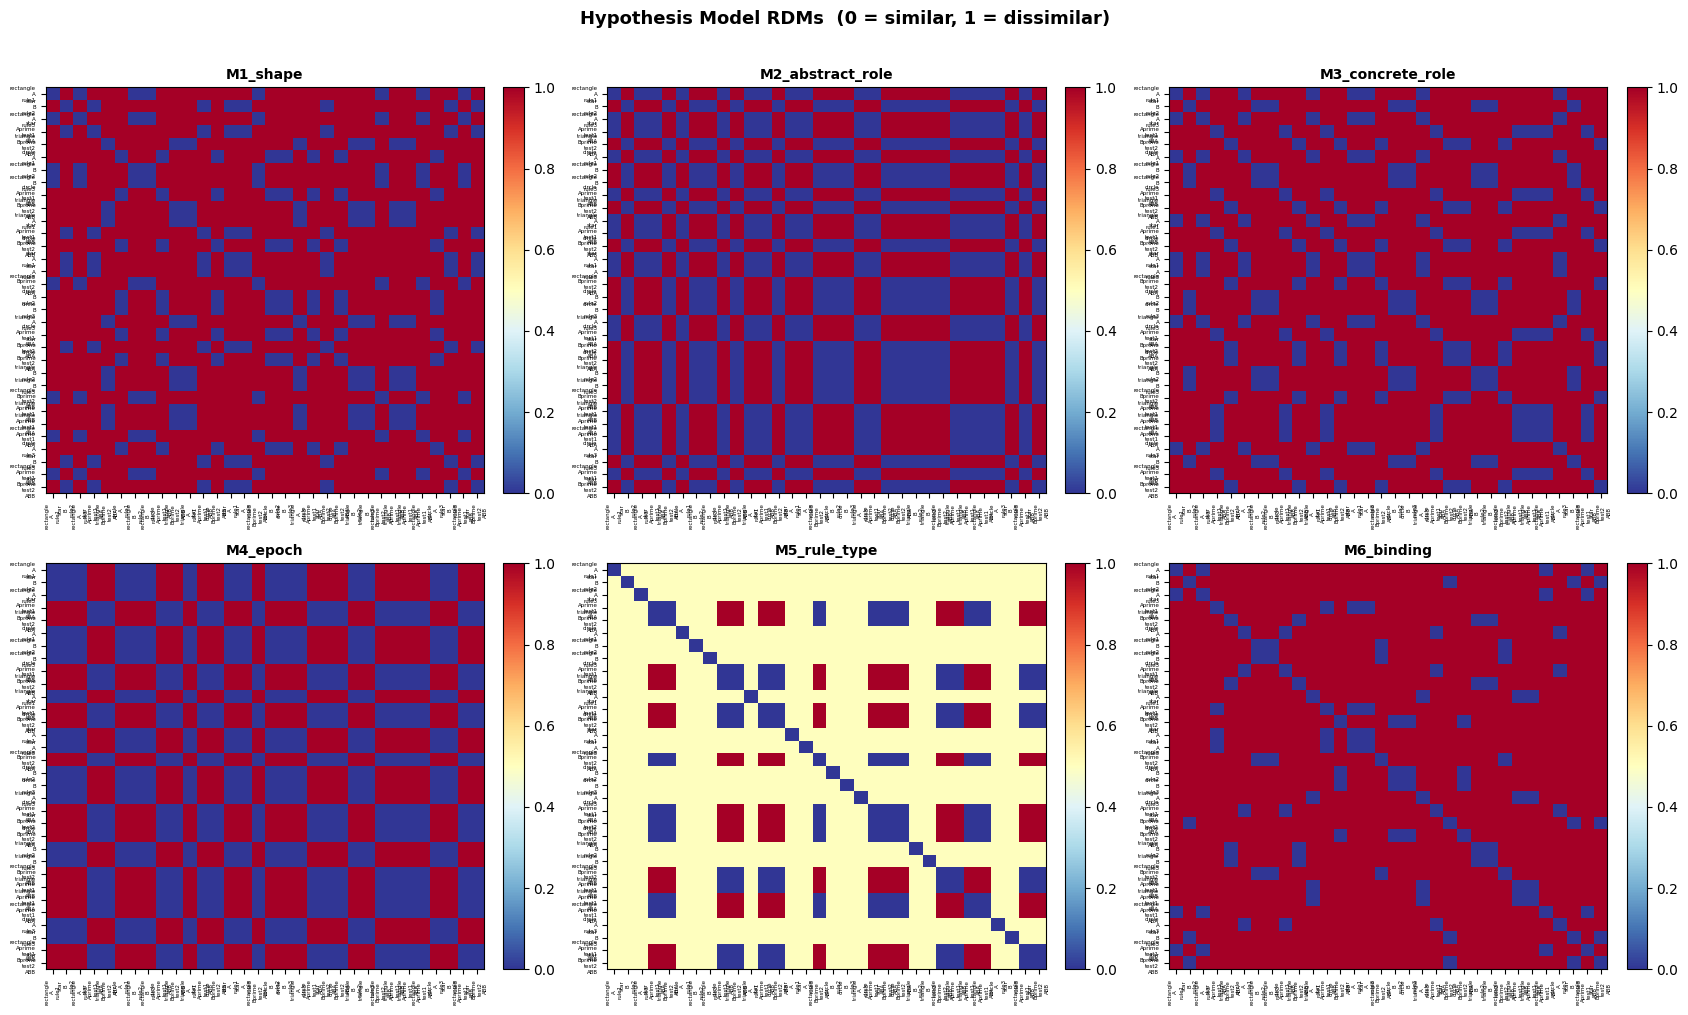

In [95]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

short_labels = [c.replace('_', '\n') for c in conditions]

for ax, (name, rdm) in zip(axes, model_rdms.items()):
    im = ax.imshow(rdm, cmap='RdYlBu_r', vmin=0, vmax=1,
                   interpolation='none', aspect='auto')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xticks(range(n_cond)); ax.set_xticklabels(short_labels, fontsize=4, rotation=90)
    ax.set_yticks(range(n_cond)); ax.set_yticklabels(short_labels, fontsize=4)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Hypothesis Model RDMs  (0 = similar, 1 = dissimilar)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'model_rdms.png'), dpi=150, bbox_inches='tight')
plt.show()

In [99]:
short_labels

['rectangle\nA\nrule1',
 'star\nB\nrule2',
 'rectangle\nA\nrule3',
 'star\nAprime\ntest1\nABA',
 'triangle\nBprime\ntest2\nABA',
 'circle\nA\nrule1',
 'rectangle\nB\nrule2',
 'rectangle\nB\nrule3',
 'circle\nAprime\ntest1\nABB',
 'triangle\nBprime\ntest2\nABB',
 'triangle\nA\nrule1',
 'star\nAprime\ntest1\nABB',
 'circle\nBprime\ntest2\nABB',
 'star\nA\nrule1',
 'star\nA\nrule3',
 'rectangle\nBprime\ntest2\nABA',
 'circle\nB\nrule2',
 'circle\nB\nrule3',
 'triangle\nA\nrule3',
 'circle\nAprime\ntest1\nABA',
 'star\nBprime\ntest2\nABA',
 'circle\nBprime\ntest2\nABA',
 'triangle\nB\nrule2',
 'triangle\nB\nrule3',
 'rectangle\nBprime\ntest2\nABB',
 'triangle\nAprime\ntest1\nABB',
 'triangle\nAprime\ntest1\nABA',
 'rectangle\nAprime\ntest1\nABA',
 'circle\nA\nrule3',
 'star\nB\nrule3',
 'rectangle\nAprime\ntest1\nABB',
 'star\nBprime\ntest2\nABB']

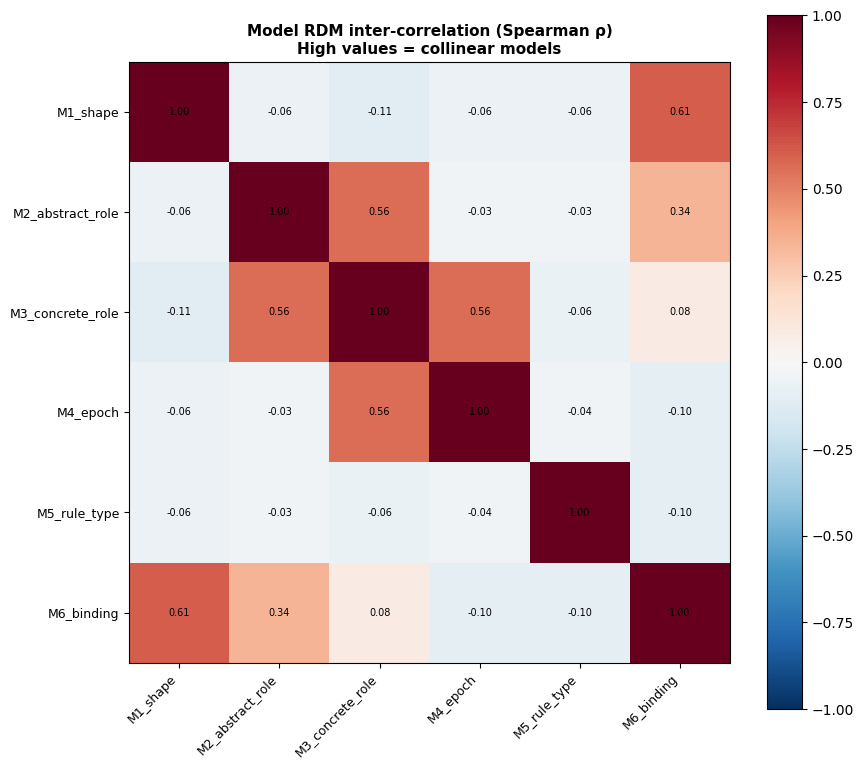


Highly collinear model pairs (|ρ| > 0.7):


In [ ]:
from scipy.stats import spearmanr

rdm_names = list(model_rdms.keys())
n_models  = len(rdm_names)
inter_corr = np.zeros((n_models, n_models))

def lower_tri(rdm):
    if rdm.ndim == 2:
        idx = squareform(rdm)
    return rdm[idx]

for i, ni in enumerate(rdm_names):
    for j, nj in enumerate(rdm_names):
        rho, _ = spearmanr(lower_tri(model_rdms[ni]),
                           lower_tri(model_rdms[nj]))
        inter_corr[i, j] = rho

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(inter_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_models)); ax.set_xticklabels(rdm_names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n_models)); ax.set_yticklabels(rdm_names, fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title('Model RDM inter-correlation (Spearman ρ)\nHigh values = collinear models', 
             fontsize=11, fontweight='bold')

for i in range(n_models):
    for j in range(n_models):
        ax.text(j, i, f'{inter_corr[i,j]:.2f}', ha='center', va='center', 
                fontsize=7, color='black')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'model_rdm_intercorr.png'), dpi=150, bbox_inches='tight')
plt.show()

# Flag highly collinear pairs
print("\nHighly collinear model pairs (|ρ| > 0.7):")
for i in range(n_models):
    for j in range(i+1, n_models):
        if abs(inter_corr[i,j]) > 0.7:
            print(f"  {rdm_names[i]} <-> {rdm_names[j]}: ρ={inter_corr[i,j]:.3f}")

In [71]:
model_rdm_vecs = {
    name: lower_tri(rdm) for name, rdm in model_rdms.items()
}

# Also save as numpy archive for later
np.savez(os.path.join(results_dir, 'model_rdms.npz'),
         conditions=np.array(conditions),
         **{name: rdm for name, rdm in model_rdms.items()})

print(f"Saved. Each RDM vector length: {len(list(model_rdm_vecs.values())[0])}")
print(f"= n*(n-1)/2 = {n_cond}*{n_cond-1}/2 = {n_cond*(n_cond-1)//2}")

Saved. Each RDM vector length: 496
= n*(n-1)/2 = 32*31/2 = 496


# RSA

In [9]:
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from joblib import Parallel, delayed
import os

In [15]:
beta_4d    = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))
conditions_ = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
                         header=None)[0].tolist()[1:]

npz        = np.load(os.path.join(results_dir, 'model_rdms.npz'), allow_pickle=True)
model_rdms = {k: npz[k] for k in npz.files if k != 'conditions'}

In [90]:
# ── 1. Load subject beta image and model RDMs ─────────────────────────────────
subject = 'sub-002'

beta_4d    = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))
conditions = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
                         header=None)[0].tolist()[1:]

npz        = np.load(os.path.join(results_dir, 'model_rdms.npz'), allow_pickle=True)
model_rdms = {k: npz[k] for k in npz.files if k != 'conditions'}

n_cond     = len(conditions)
print(f"Beta image shape : {beta_4d.shape}")   # (x, y, z, n_cond)
print(f"N conditions     : {n_cond}")
print(f"Model RDMs       : {list(model_rdms.keys())}")

# ── 2. Prepare data arrays and brain mask ─────────────────────────────────────
beta_data  = beta_4d.get_fdata()               # (x, y, z, n_cond)
affine     = beta_4d.affine
vox_size   = np.abs(np.diag(affine)[:3])       # mm per voxel, e.g. [2,2,2]

# Brain mask: voxels that are non-zero in ALL condition maps
# (any voxel outside the mask will be all-zeros from the GLM)
mask_data  = np.all(beta_data != 0, axis=-1)   # (x, y, z) bool
print(f"In-mask voxels   : {mask_data.sum()}")

# Coordinates of all in-mask voxels
vox_coords   = np.array(np.where(mask_data)).T     # (n_voxels, 3) — voxel indices
world_coords = nib.affines.apply_affine(affine, vox_coords)  # (n_voxels, 3) — mm
n_vox        = len(vox_coords)
print(f"Total searchlight centers: {n_vox}")
# ── 3. Precompute model RDM lower-triangle vectors ────────────────────────────
def lower_tri(rdm):
    idx = np.tril_indices(rdm.shape[0], k=-1)
    return rdm[idx]

model_vecs  = {name: lower_tri(rdm) for name, rdm in model_rdms.items()}
model_names = list(model_vecs.keys())
n_models    = len(model_names)
vec_len     = n_cond * (n_cond - 1) // 2
print(f"RDM vector length: {vec_len}  (= {n_cond}*{n_cond-1}/2)")
# ── 4. Core searchlight function (one center voxel) ───────────────────────────
RADIUS_MM = 12.0   # standard for whole-brain RSA; reduce to 9 for finer resolution

def searchlight_one_voxel(center_idx):
    """
    For a single searchlight center:
      1. Find all in-mask voxels within RADIUS_MM
      2. Extract (n_cond, n_neighbors) pattern matrix
      3. Compute neural RDM via correlation distance
      4. Spearman rho against each model RDM vector
    Returns array of shape (n_models,) — one rho per model.
    """
    center_vox = vox_coords[center_idx]           # (3,)

    # Euclidean distance in voxel space, scaled to mm
    dists_mm   = np.sqrt(((vox_coords - center_vox) ** 2 * vox_size**2).sum(axis=1))
    neighbor_idx = np.where(dists_mm <= RADIUS_MM)[0]

    if len(neighbor_idx) < n_cond:
        # Too few voxels in sphere to form a meaningful RDM
        return np.full(n_models, np.nan)

    # Pattern matrix: (n_cond, n_neighbors)
    nv = vox_coords[neighbor_idx]
    patterns = beta_data[nv[:, 0], nv[:, 1], nv[:, 2], :].T   # (n_cond, n_neighbors)

    # Neural RDM lower triangle: correlation distance
    neural_vec = pdist(patterns, metric='correlation')          # (vec_len,)

    # Spearman rho against each model
    rhos = np.array([
        spearmanr(neural_vec, model_vecs[name])[0]
        for name in model_names
    ])
    return rhos   # (n_models,)/M

Beta image shape : (97, 115, 97, 32)
N conditions     : 32
Model RDMs       : ['M1_shape', 'M2_abstract_role', 'M3_concrete_role', 'M4_epoch', 'M5_rule_type', 'M6_binding']
In-mask voxels   : 85818
Total searchlight centers: 85818
RDM vector length: 496  (= 32*31/2)


In [78]:
# ── 5. Run searchlight in parallel ────────────────────────────────────────────
# n_jobs=-1 uses all available cores; reduce if memory is tight
# For a 2mm whole-brain grid (~50k-200k voxels) expect ~20-60 min depending on hardware

print(f"Launching searchlight over {n_vox} voxels with radius={RADIUS_MM}mm ...")
print(f"Using joblib parallel backend ...")

results_list = Parallel(n_jobs=-1, verbose=5)(
    delayed(searchlight_one_voxel)(i) for i in range(n_vox)
)

# results_list: list of (n_models,) arrays, length n_vox
results_arr = np.array(results_list)    # (n_vox, n_models)
print(f"Done. Results shape: {results_arr.shape}")

Launching searchlight over 85818 voxels with radius=12.0mm ...
Using joblib parallel backend ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 612 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 2668 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 6412 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 10732 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 15628 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 21100 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done 27148 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 33772 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 40972 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 48748 tasks      | elapsed:   18.0s
[Parallel(n_jobs=-1)]: Done 57100 tasks      | elapsed:   20.6s
[Parallel(n_jobs=-1)]: Done 66028 tasks      | elapsed:   23.5s
[Parallel(n_jobs=-1)]: Done 75532 t

Done. Results shape: (85818, 6)


[Parallel(n_jobs=-1)]: Done 85818 out of 85818 | elapsed:   30.0s finished


In [79]:
# ── 6. Unpack results into one NIfTI per model RDM ────────────────────────────
rsa_imgs = {}

for m_idx, name in enumerate(model_names):
    rsa_map = np.full(beta_data.shape[:3], np.nan)
    rsa_map[vox_coords[:, 0],
            vox_coords[:, 1],
            vox_coords[:, 2]] = results_arr[:, m_idx]

    img = nib.Nifti1Image(rsa_map, affine)
    out_path = os.path.join(results_dir, f'{subject}_searchlight_rho_{name}.nii.gz')
    img.to_filename(out_path)
    rsa_imgs[name] = img
    print(f"Saved: {out_path}  |  "
          f"non-nan voxels: {(~np.isnan(rsa_map)).sum()}  |  "
          f"mean rho: {np.nanmean(rsa_map):.4f}  |  "
          f"max rho: {np.nanmax(rsa_map):.4f}")

Saved: rsa_results/sub-002_searchlight_rho_M1_shape.nii.gz  |  non-nan voxels: 85806  |  mean rho: 0.0218  |  max rho: 0.0825
Saved: rsa_results/sub-002_searchlight_rho_M2_abstract_role.nii.gz  |  non-nan voxels: 85806  |  mean rho: 0.0092  |  max rho: 0.0568
Saved: rsa_results/sub-002_searchlight_rho_M3_concrete_role.nii.gz  |  non-nan voxels: 85806  |  mean rho: -0.0064  |  max rho: 0.0494
Saved: rsa_results/sub-002_searchlight_rho_M4_epoch.nii.gz  |  non-nan voxels: 85806  |  mean rho: 0.0155  |  max rho: 0.0683
Saved: rsa_results/sub-002_searchlight_rho_M5_rule_type.nii.gz  |  non-nan voxels: 85806  |  mean rho: -0.0241  |  max rho: 0.0769
Saved: rsa_results/sub-002_searchlight_rho_M6_binding.nii.gz  |  non-nan voxels: 85806  |  mean rho: 0.0054  |  max rho: 0.0430


In [91]:
# load the results again
rsa_imgs = {}
for name in model_names:
    path = os.path.join(results_dir, f'{subject}_searchlight_rho_{name}.nii.gz')
    rsa_imgs[name] = nib.load(path)
    print(f"Loaded: {path}  |  shape: {rsa_imgs[name].shape}")


Loaded: rsa_results/sub-002_searchlight_rho_M1_shape.nii.gz  |  shape: (97, 115, 97)
Loaded: rsa_results/sub-002_searchlight_rho_M2_abstract_role.nii.gz  |  shape: (97, 115, 97)
Loaded: rsa_results/sub-002_searchlight_rho_M3_concrete_role.nii.gz  |  shape: (97, 115, 97)
Loaded: rsa_results/sub-002_searchlight_rho_M4_epoch.nii.gz  |  shape: (97, 115, 97)
Loaded: rsa_results/sub-002_searchlight_rho_M5_rule_type.nii.gz  |  shape: (97, 115, 97)
Loaded: rsa_results/sub-002_searchlight_rho_M6_binding.nii.gz  |  shape: (97, 115, 97)


/tmp/ipykernel_1138068/1680148110.py:5: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  display = plotting.plot_stat_map(


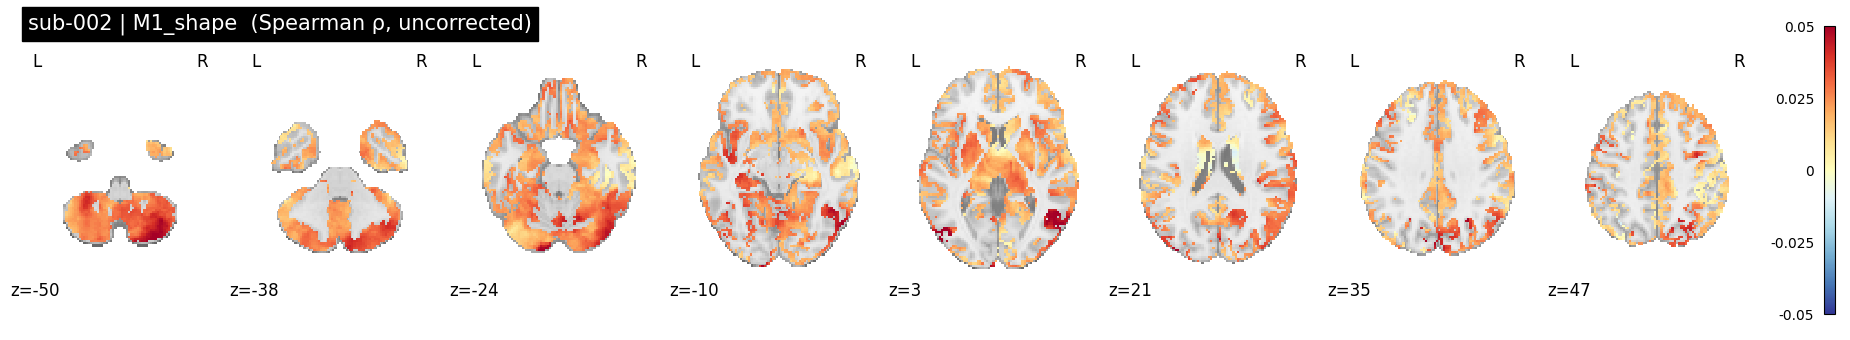

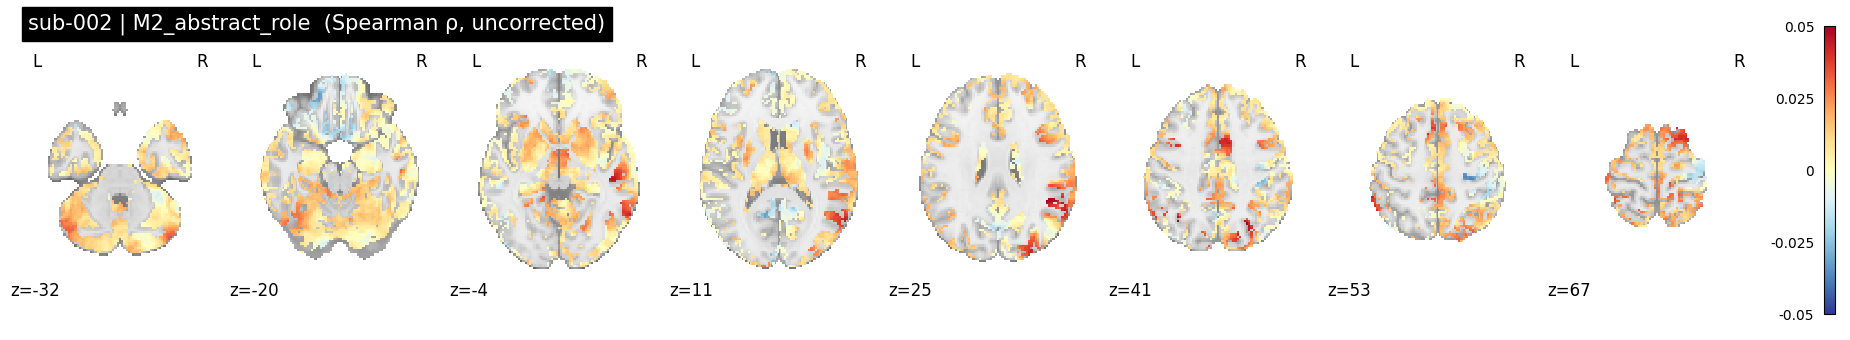

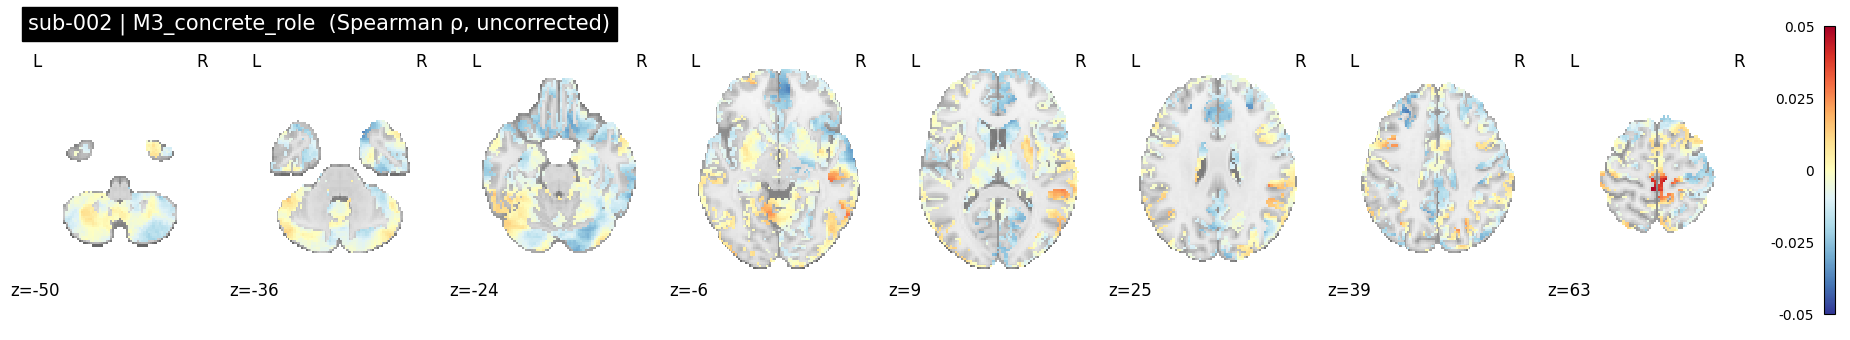

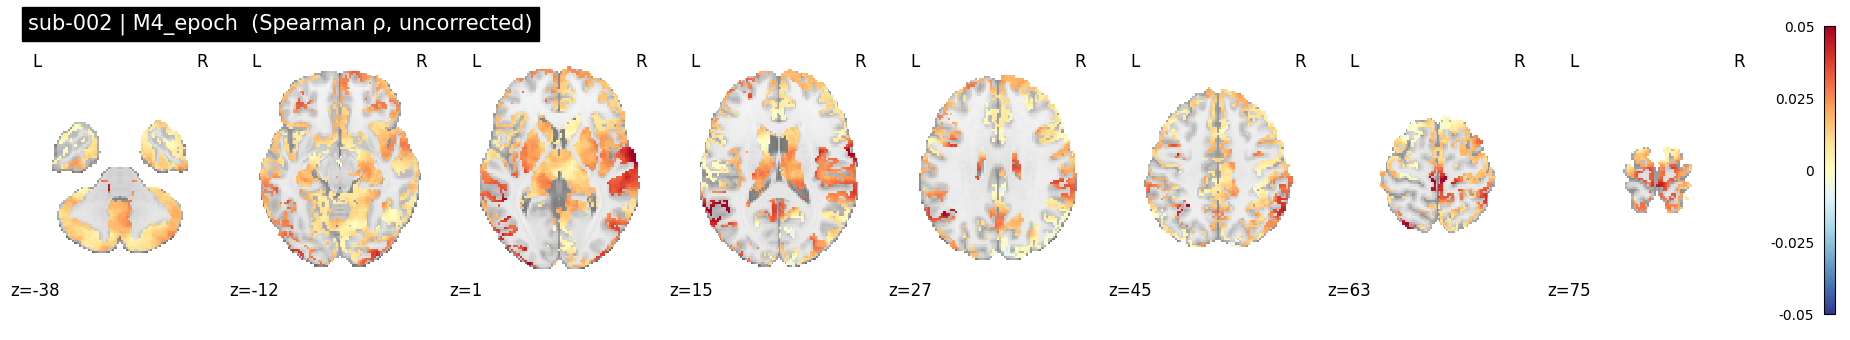

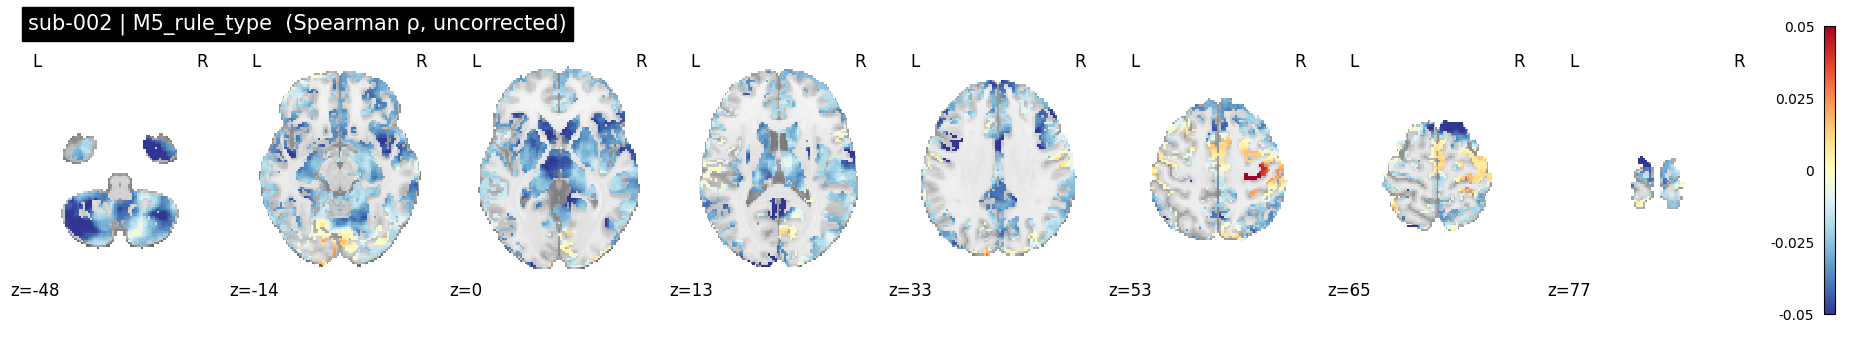

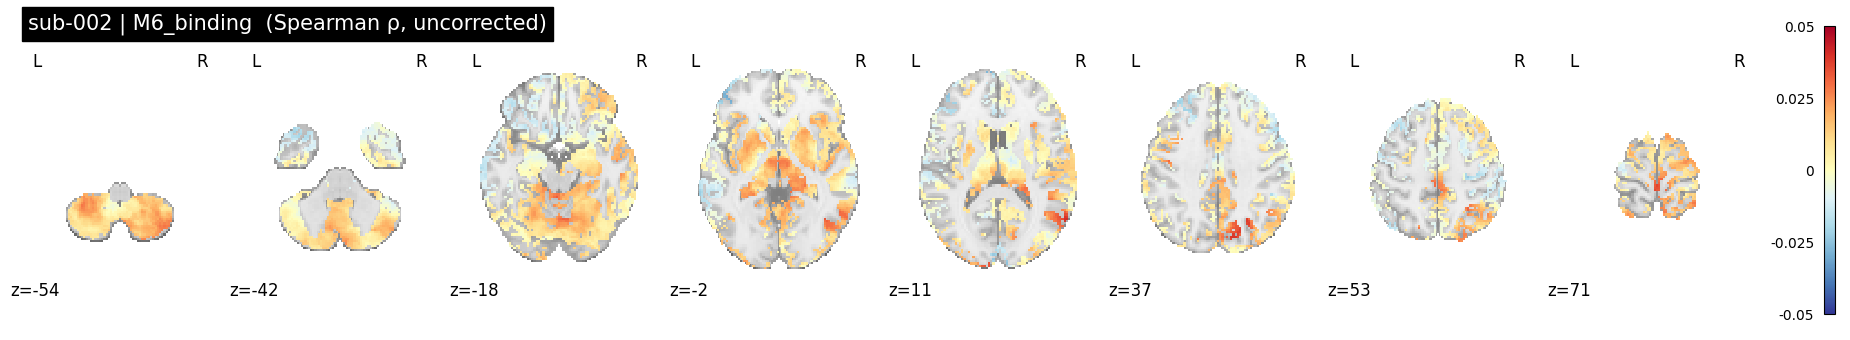

In [92]:
# ── 7. Quick visualization of each RSA map ────────────────────────────────────
from nilearn import plotting

for name, img in rsa_imgs.items():
    display = plotting.plot_stat_map(
        img,
        threshold   = 0.00,             # low threshold for exploration — not corrected
        display_mode= 'z',
        cut_coords  = 8,
        colorbar    = True,
        cmap        = 'RdYlBu_r',
        vmax        = 0.05,
        title       = f'{subject} | {name}  (Spearman ρ, uncorrected)'
    )
    display.savefig(os.path.join(results_dir, f'{subject}_searchlight_{name}.png'), dpi=120)
    plt.show()

In [81]:
# ── 1. Load subject beta image and model RDMs ─────────────────────────────────
subject = 'sub-008'

beta_4d    = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))
conditions = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
                         header=None)[0].tolist()[1:]

npz        = np.load(os.path.join(results_dir, 'model_rdms.npz'), allow_pickle=True)
model_rdms = {k: npz[k] for k in npz.files if k != 'conditions'}

n_cond     = len(conditions)
print(f"Beta image shape : {beta_4d.shape}")   # (x, y, z, n_cond)
print(f"N conditions     : {n_cond}")
print(f"Model RDMs       : {list(model_rdms.keys())}")

# ── 2. Prepare data arrays and brain mask ─────────────────────────────────────
beta_data  = beta_4d.get_fdata()               # (x, y, z, n_cond)
affine     = beta_4d.affine
vox_size   = np.abs(np.diag(affine)[:3])       # mm per voxel, e.g. [2,2,2]

# Brain mask: voxels that are non-zero in ALL condition maps
# (any voxel outside the mask will be all-zeros from the GLM)
mask_data  = np.all(beta_data != 0, axis=-1)   # (x, y, z) bool
print(f"In-mask voxels   : {mask_data.sum()}")

# Coordinates of all in-mask voxels
vox_coords   = np.array(np.where(mask_data)).T     # (n_voxels, 3) — voxel indices
world_coords = nib.affines.apply_affine(affine, vox_coords)  # (n_voxels, 3) — mm
n_vox        = len(vox_coords)
print(f"Total searchlight centers: {n_vox}")
# ── 3. Precompute model RDM lower-triangle vectors ────────────────────────────
def lower_tri(rdm):
    idx = np.tril_indices(rdm.shape[0], k=-1)
    return rdm[idx]

model_vecs  = {name: lower_tri(rdm) for name, rdm in model_rdms.items()}
model_names = list(model_vecs.keys())
n_models    = len(model_names)
vec_len     = n_cond * (n_cond - 1) // 2
print(f"RDM vector length: {vec_len}  (= {n_cond}*{n_cond-1}/2)")
# ── 4. Core searchlight function (one center voxel) ───────────────────────────
RADIUS_MM = 12.0   # standard for whole-brain RSA; reduce to 9 for finer resolution

def searchlight_one_voxel(center_idx):
    """
    For a single searchlight center:
      1. Find all in-mask voxels within RADIUS_MM
      2. Extract (n_cond, n_neighbors) pattern matrix
      3. Compute neural RDM via correlation distance
      4. Spearman rho against each model RDM vector
    Returns array of shape (n_models,) — one rho per model.
    """
    center_vox = vox_coords[center_idx]           # (3,)

    # Euclidean distance in voxel space, scaled to mm
    dists_mm   = np.sqrt(((vox_coords - center_vox) ** 2 * vox_size**2).sum(axis=1))
    neighbor_idx = np.where(dists_mm <= RADIUS_MM)[0]

    if len(neighbor_idx) < n_cond:
        # Too few voxels in sphere to form a meaningful RDM
        return np.full(n_models, np.nan)

    # Pattern matrix: (n_cond, n_neighbors)
    nv = vox_coords[neighbor_idx]
    patterns = beta_data[nv[:, 0], nv[:, 1], nv[:, 2], :].T   # (n_cond, n_neighbors)

    # Neural RDM lower triangle: correlation distance
    neural_vec = pdist(patterns, metric='correlation')          # (vec_len,)

    # Spearman rho against each model
    rhos = np.array([
        spearmanr(neural_vec, model_vecs[name])[0]
        for name in model_names
    ])
    return rhos   # (n_models,)/M

Beta image shape : (97, 115, 97, 32)
N conditions     : 32
Model RDMs       : ['M1_shape', 'M2_abstract_role', 'M3_concrete_role', 'M4_epoch', 'M5_rule_type', 'M6_binding']
In-mask voxels   : 80507
Total searchlight centers: 80507
RDM vector length: 496  (= 32*31/2)


In [82]:
# ── 5. Run searchlight in parallel ────────────────────────────────────────────
# n_jobs=-1 uses all available cores; reduce if memory is tight
# For a 2mm whole-brain grid (~50k-200k voxels) expect ~20-60 min depending on hardware

print(f"Launching searchlight over {n_vox} voxels with radius={RADIUS_MM}mm ...")
print(f"Using joblib parallel backend ...")

results_list = Parallel(n_jobs=-1, verbose=5)(
    delayed(searchlight_one_voxel)(i) for i in range(n_vox)
)

# results_list: list of (n_models,) arrays, length n_vox
results_arr = np.array(results_list)    # (n_vox, n_models)
print(f"Done. Results shape: {results_arr.shape}")

Launching searchlight over 80507 voxels with radius=12.0mm ...
Using joblib parallel backend ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 612 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 2060 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 3932 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 6092 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 8540 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 11276 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 17292 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 23916 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 31116 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done 38892 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 47244 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done 56172 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 65676 tas

Done. Results shape: (80507, 6)


[Parallel(n_jobs=-1)]: Done 80507 out of 80507 | elapsed:   25.9s finished


In [83]:
# ── 6. Unpack results into one NIfTI per model RDM ────────────────────────────
rsa_imgs = {}

for m_idx, name in enumerate(model_names):
    rsa_map = np.full(beta_data.shape[:3], np.nan)
    rsa_map[vox_coords[:, 0],
            vox_coords[:, 1],
            vox_coords[:, 2]] = results_arr[:, m_idx]

    img = nib.Nifti1Image(rsa_map, affine)
    out_path = os.path.join(results_dir, f'{subject}_searchlight_rho_{name}.nii.gz')
    img.to_filename(out_path)
    rsa_imgs[name] = img
    print(f"Saved: {out_path}  |  "
          f"non-nan voxels: {(~np.isnan(rsa_map)).sum()}  |  "
          f"mean rho: {np.nanmean(rsa_map):.4f}  |  "
          f"max rho: {np.nanmax(rsa_map):.4f}")

Saved: rsa_results/sub-008_searchlight_rho_M1_shape.nii.gz  |  non-nan voxels: 80461  |  mean rho: 0.0198  |  max rho: 0.0581
Saved: rsa_results/sub-008_searchlight_rho_M2_abstract_role.nii.gz  |  non-nan voxels: 80461  |  mean rho: 0.0028  |  max rho: 0.0539
Saved: rsa_results/sub-008_searchlight_rho_M3_concrete_role.nii.gz  |  non-nan voxels: 80461  |  mean rho: -0.0054  |  max rho: 0.0546
Saved: rsa_results/sub-008_searchlight_rho_M4_epoch.nii.gz  |  non-nan voxels: 80461  |  mean rho: 0.0228  |  max rho: 0.0744
Saved: rsa_results/sub-008_searchlight_rho_M5_rule_type.nii.gz  |  non-nan voxels: 80461  |  mean rho: -0.0243  |  max rho: 0.0448
Saved: rsa_results/sub-008_searchlight_rho_M6_binding.nii.gz  |  non-nan voxels: 80461  |  mean rho: 0.0001  |  max rho: 0.0507


/tmp/ipykernel_1138068/1680148110.py:5: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  display = plotting.plot_stat_map(


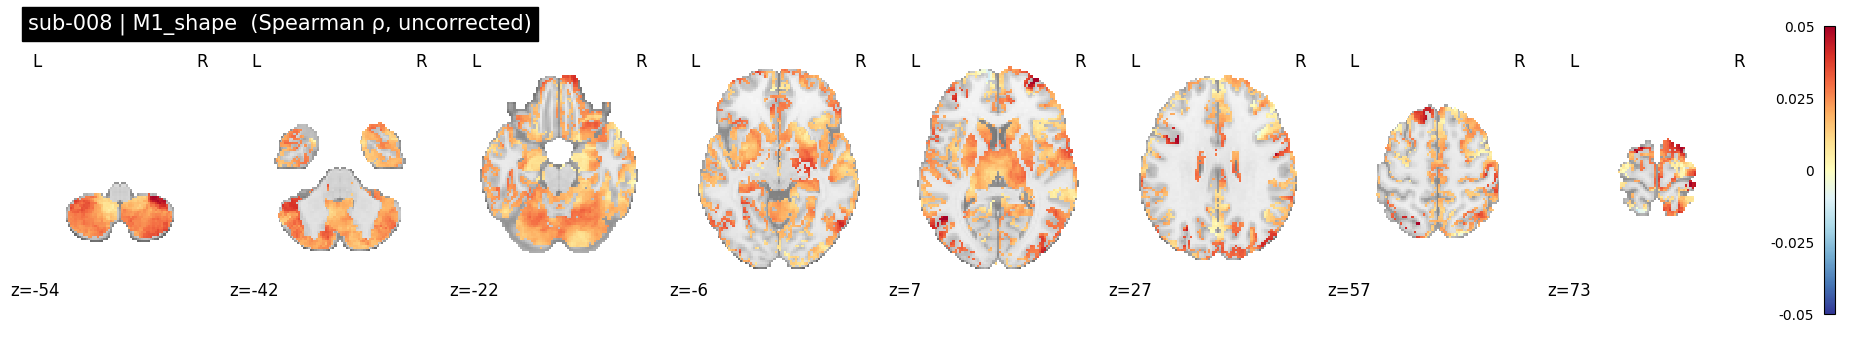

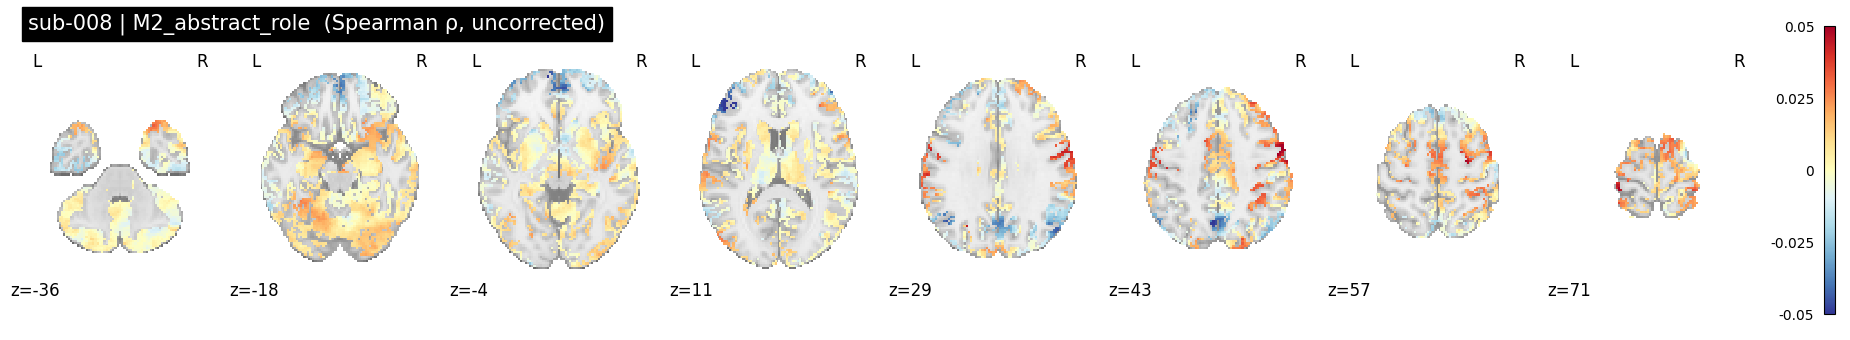

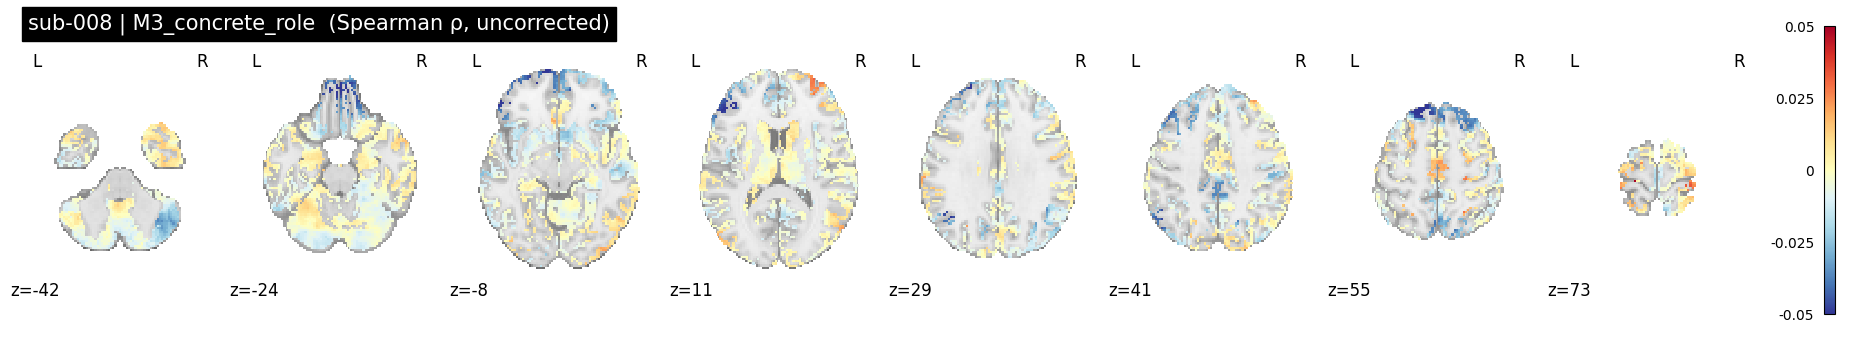

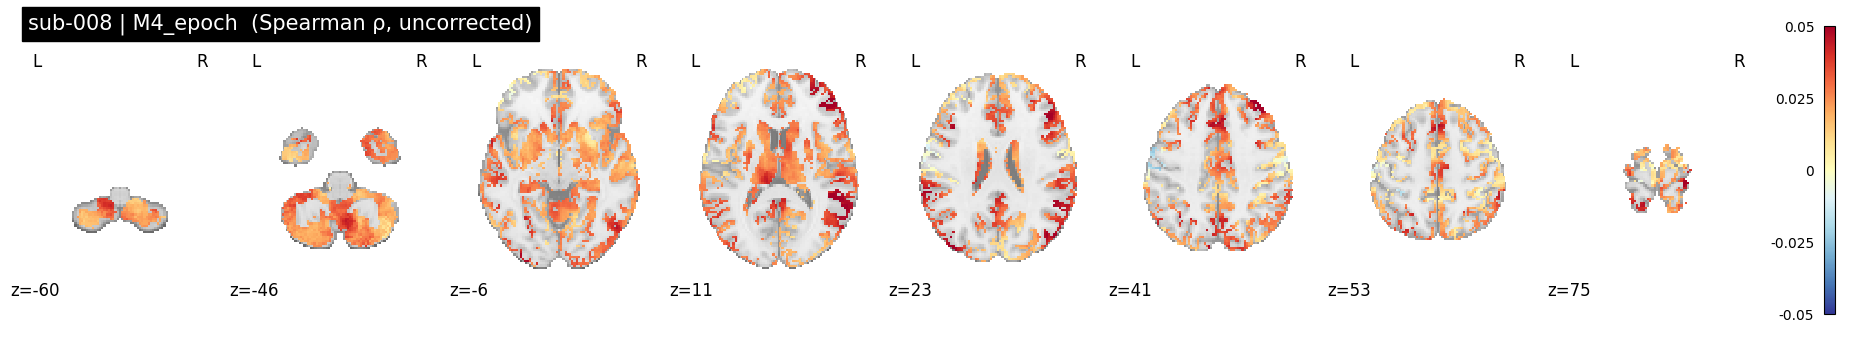

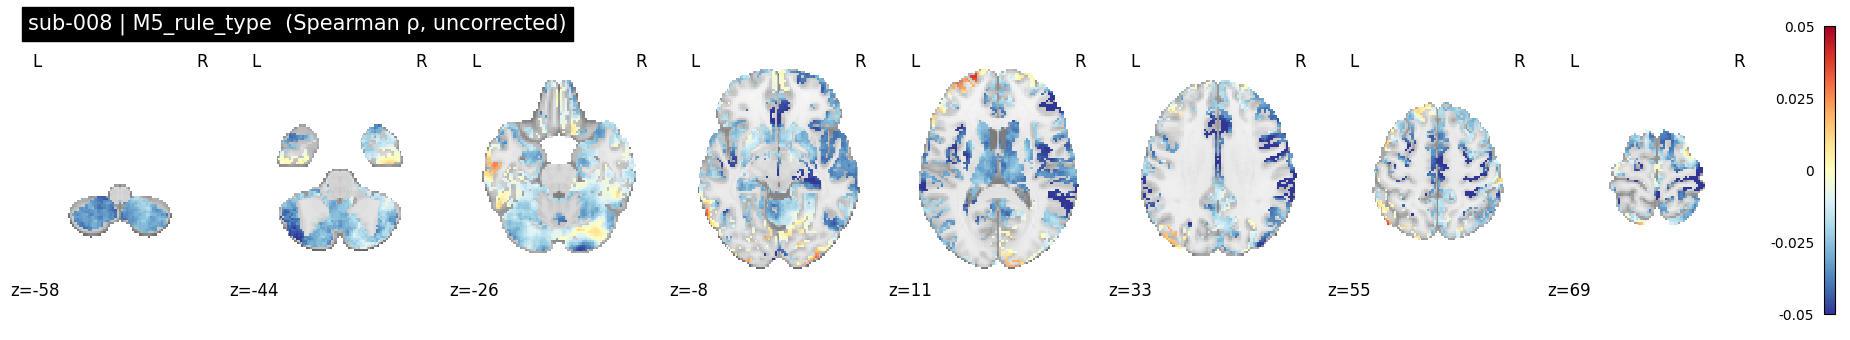

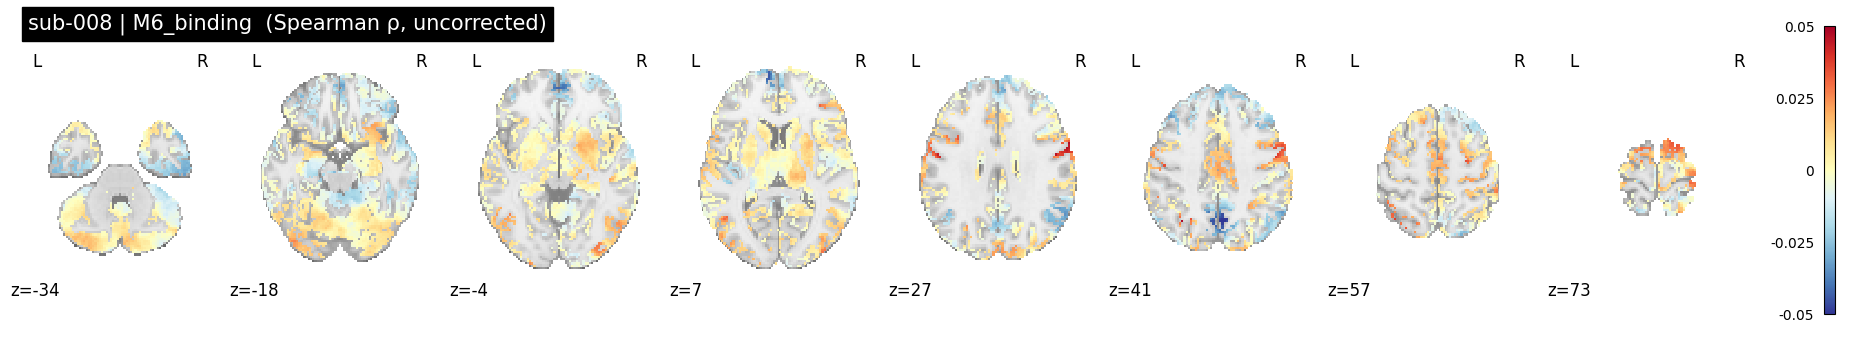

In [89]:
# ── 7. Quick visualization of each RSA map ────────────────────────────────────
from nilearn import plotting

for name, img in rsa_imgs.items():
    display = plotting.plot_stat_map(
        img,
        threshold   = 0.00,             # low threshold for exploration — not corrected
        display_mode= 'z',
        cut_coords  = 8,
        colorbar    = True,
        cmap        = 'RdYlBu_r',
        vmax        = 0.05,
        title       = f'{subject} | {name}  (Spearman ρ, uncorrected)'
    )
    display.savefig(os.path.join(results_dir, f'{subject}_searchlight_{name}.png'), dpi=120)
    plt.show()

# Focused search

In [13]:
# Test-phase conditions only
test_conditions = [c for c in conditions 
                   if 'test' in parse_condition(c)['phase']]
n_test = len(test_conditions)
meta_test = meta.loc[test_conditions]

def make_rdm_test(conditions, sim_fn):
    n = len(conditions)
    rdm = np.zeros((n, n))
    for i, ci in enumerate(conditions):
        for j, cj in enumerate(conditions):
            rdm[i, j] = 1.0 - sim_fn(meta_test.loc[ci], meta_test.loc[cj])
    np.fill_diagonal(rdm, 0)
    return rdm

# M_shape — same as before, restricted to test phase
def sim_shape_test(a, b):
    return float(a['shape'] == b['shape'])

M_shape_test = make_rdm_test(test_conditions, sim_shape_test)

# M_abstract — A' clusters with A', B' clusters with B', across rule types
# i.e. ABA-Aprime similar to ABB-Aprime
def sim_abstract_test(a, b):
    return float(a['role'] == b['role'])   # Aprime==Aprime, Bprime==Bprime

M_abstract_test = make_rdm_test(test_conditions, sim_abstract_test)

# M_functional — repeater clusters with repeater, regardless of position label
# In ABA: Aprime is the repeater (circle repeats)
# In ABB: Bprime is the repeater (triangle repeats)
def is_repeater(meta_row):
    if meta_row['rule_type'] == 'ABA':
        return meta_row['role'] == 'Aprime'   # A repeats in ABA
    else:
        return meta_row['role'] == 'Bprime'   # B repeats in ABB

def sim_functional_test(a, b):
    return float(is_repeater(a) == is_repeater(b))

M_functional_test = make_rdm_test(test_conditions, sim_functional_test)

model_rdms_test = {
    'shape_test':    M_shape_test,
    'abstract_test': M_abstract_test,
    'functional_test': M_functional_test,
}

NameError: name 'conditions' is not defined

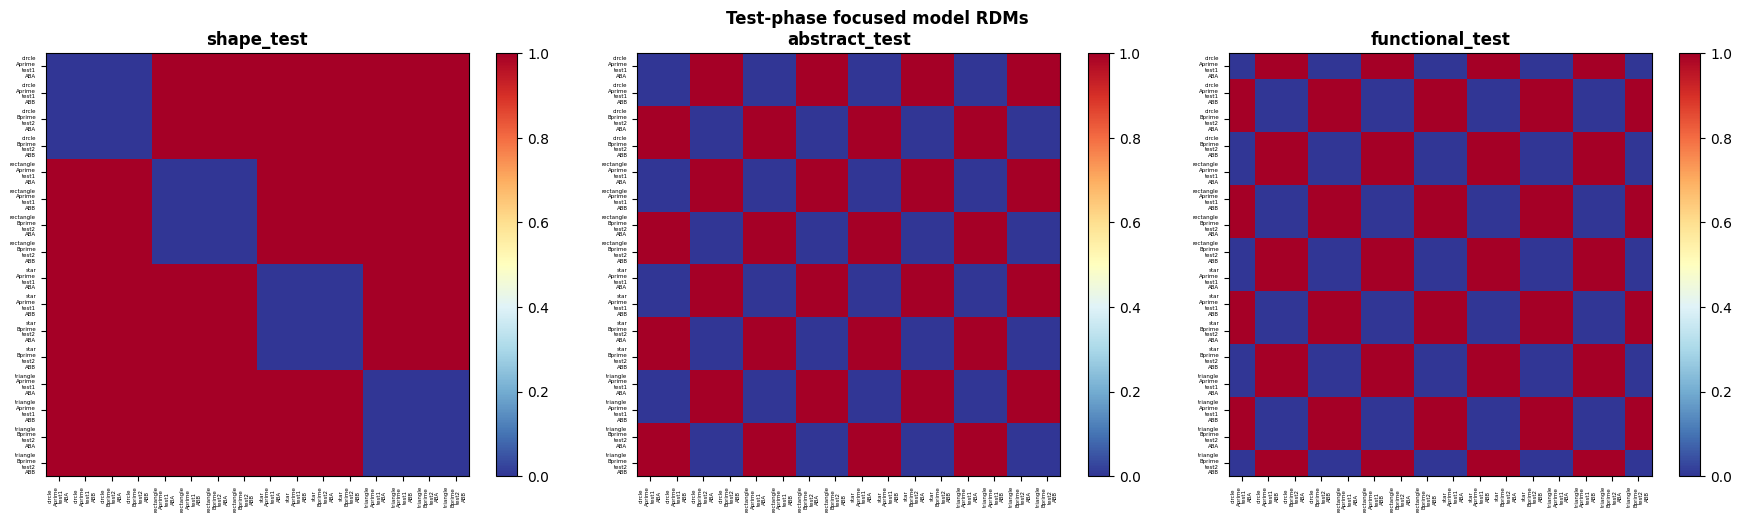

Abstract vs Functional RDM correlation: ρ=-0.071, p=0.4382


In [96]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
short = [c.replace('_', '\n') for c in test_conditions]

for ax, (name, rdm) in zip(axes, model_rdms_test.items()):
    im = ax.imshow(rdm, cmap='RdYlBu_r', vmin=0, vmax=1)
    ax.set_title(name, fontweight='bold')
    ax.set_xticks(range(n_test)); ax.set_xticklabels(short, fontsize=4, rotation=90)
    ax.set_yticks(range(n_test)); ax.set_yticklabels(short, fontsize=4)
    plt.colorbar(im, ax=ax)

plt.suptitle('Test-phase focused model RDMs', fontweight='bold')
plt.tight_layout()
plt.show()

# Check anti-correlation — should be strongly negative
from scipy.stats import spearmanr
rho, p = spearmanr(lower_tri(M_abstract_test), lower_tri(M_functional_test))
print(f"Abstract vs Functional RDM correlation: ρ={rho:.3f}, p={p:.4f}")
# Expect strongly negative — confirms clean dissociation

In [46]:
import itertools
m_abstract = get_lower_tri(model_rdms['abstract_test'])
m_functional = get_lower_tri(model_rdms['functional_test'])
# Verify this decomposition
within_rule = []
cross_rule  = []

for idx, (c1, c2) in enumerate(itertools.combinations(conditions, 2)):
    p1, p2 = parse_condition(c1), parse_condition(c2)
    if p1['rule_type'] == p2['rule_type']:
        within_rule.append(idx)
    else:
        cross_rule.append(idx)

rho_within, _ = spearmanr(m_abstract[within_rule], m_functional[within_rule])
rho_cross,  _ = spearmanr(m_abstract[cross_rule],  m_functional[cross_rule])

print(f"Abstract vs Functional correlation:")
print(f"  within-rule entries : ρ = {rho_within:.3f}")   # expect ≈ +1.0
print(f"  cross-rule entries  : ρ = {rho_cross:.3f}")    # expect ≈ -1.0
print(f"  overall             : ρ = {spearmanr(m_abstract, m_functional)[0]:.3f}")

Abstract vs Functional correlation:
  within-rule entries : ρ = 0.133
  cross-rule entries  : ρ = -0.251
  overall             : ρ = -0.071


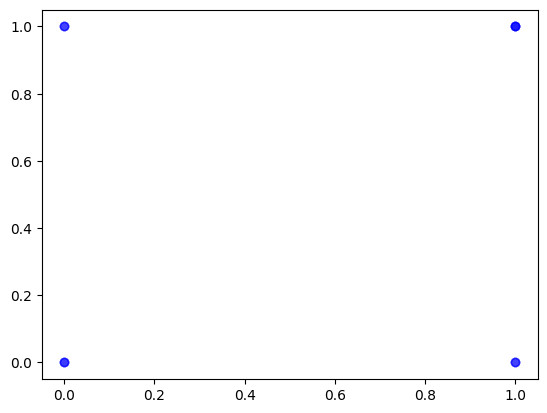

In [50]:
plt.scatter(m_abstract[within_rule], m_functional[within_rule], color='blue', label='Within-rule', alpha=0.1)

In [126]:
# save the test-phase RDMs as well
model_rdms_test1 = {
    'shape_test':    M_shape_test,
    'abstract_test': M_abstract_test,
}
np.savez(os.path.join(results_dir, 'model_rdms_test1.npz'), 
         conditions=np.array(test_conditions),
         **{name: rdm for name, rdm in model_rdms_test1.items()})

# save the test-phase RDMs as well
model_rdms_test2 = {
    'shape_test':    M_shape_test,
    'functional_test': M_functional_test,
}
np.savez(os.path.join(results_dir, 'model_rdms_test2.npz'), 
         conditions=np.array(test_conditions),
         **{name: rdm for name, rdm in model_rdms_test2.items()})

In [ ]:

_beta_data = None
_vox_coords = None
_vox_size = None
_model_vecs = None
_model_names = None
_n_cond = None
_RADIUS_MM = None

def searchlight_one_voxel(center_idx, beta_data, vox_coords, vox_size,
                           model_vecs, model_names, n_cond, radius_mm):
    try:
        center_vox   = vox_coords[center_idx]
        dists_mm     = np.sqrt(((vox_coords - center_vox)**2 * vox_size**2).sum(axis=1))
        neighbor_idx = np.where(dists_mm <= radius_mm)[0]

        if len(neighbor_idx) < n_cond:
            return np.full(len(model_names), np.nan)

        nv         = vox_coords[neighbor_idx]
        patterns   = beta_data[nv[:,0], nv[:,1], nv[:,2], :].T
        neural_vec = pdist(patterns, metric='correlation')

        return np.array([
            spearmanr(neural_vec, model_vecs[n])[0]
            for n in model_names
        ])
    except Exception:
        return np.full(len(model_names), np.nan)
for i, model_path in enumerate(['model_rdms_test1.npz', 'model_rdms_test2.npz']):
    if i == 0: 
        continue
    # ── 1. Main subject loop ──────────────────────────────────────────────────────
    for subject in ['sub-002', 'sub-008']:
        print(f'\n=== {subject} ===')

        # Load beta image and conditions
        # beta_4d    = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))
        # conditions = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
        #                          header=None)[0].tolist()[1:]
        # conditions = [c for c in pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
        #                          header=None)[0].tolist()[1:]
        #           if 'test' in parse_condition(c)['phase']]
        beta_4d    = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))

        all_conditions = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
                                    header=None)[0].tolist()[1:]
        conditions = [c for c in all_conditions if 'test' in parse_condition(c)['phase']]
        test_indices = [all_conditions.index(c) for c in conditions]
        from nilearn.image import index_img
        beta_4d = index_img(beta_4d, test_indices)   # (x, y, z, n_test_cond)
        n_cond     = len(conditions)
        print(f"Beta image shape : {beta_4d.shape}")
        print(f"N conditions     : {n_cond}")

        # Load model RDMs
        npz        = np.load(os.path.join(results_dir, model_path), allow_pickle=True)
        model_rdms = {k: npz[k] for k in npz.files if k != 'conditions'}
        model_vecs  = {name: lower_tri(rdm) for name, rdm in model_rdms.items()}
        model_names = list(model_vecs.keys())
        print(f"Model RDMs       : {model_names}")

        # Dimension check — must pass before launching
        expected_vec_len = 120
        for name, vec in model_vecs.items():
            assert len(vec) == expected_vec_len, \
                f"{name}: model vec length {len(vec)} != expected {expected_vec_len}"
        print(f"Dimension check passed — RDM vec length: {expected_vec_len}")

        # Prepare arrays
        beta_data  = beta_4d.get_fdata()                          # (x, y, z, n_cond)
        affine     = beta_4d.affine
        vox_size   = np.abs(np.diag(affine)[:3])
        mask_data  = np.all(beta_data != 0, axis=-1)              # (x, y, z) bool
        vox_coords = np.array(np.where(mask_data)).T              # (n_voxels, 3)
        n_vox      = len(vox_coords)
        print(f"In-mask voxels   : {mask_data.sum()}")
        print(f"Searchlight centers: {n_vox}")

        # Assign globals for worker function
        global _beta_data, _vox_coords, _vox_size
        global _model_vecs, _model_names, _n_cond
        _beta_data   = beta_data
        _vox_coords  = vox_coords
        _vox_size    = vox_size
        _model_vecs  = model_vecs
        _model_names = model_names
        _n_cond      = n_cond
        RADIUS_MM = 12.0

        # Run searchlight
        print(f"Launching searchlight (radius={_RADIUS_MM}mm) ...")
        # results_list = Parallel(n_jobs=-1, verbose=5)(
        #     delayed(searchlight_one_voxel)(i) for i in range(n_vox)
        # )
        results_list = Parallel(n_jobs=-1, verbose=5)(
            delayed(searchlight_one_voxel)(
                i,
                beta_data,
                vox_coords,
                vox_size,
                model_vecs,
                model_names,
                n_cond,
                RADIUS_MM
            )
            for i in range(n_vox)
        )
        results_arr = np.array(results_list)    # (n_vox, n_models)
        print(f"Done. Results shape: {results_arr.shape}")

        # Save one NIfTI per model RDM
        for m_idx, name in enumerate(model_names):
            rsa_map = np.full(beta_data.shape[:3], np.nan)
            rsa_map[vox_coords[:,0],
                    vox_coords[:,1],
                    vox_coords[:,2]] = results_arr[:, m_idx]

            img      = nib.Nifti1Image(rsa_map, affine)
            out_path = os.path.join(results_dir, f'{subject}_searchlight_rho_{name}_{i}.nii.gz')
            img.to_filename(out_path)
            print(f"Saved: {out_path}  |  "
                f"non-nan: {(~np.isnan(rsa_map)).sum()}  |  "
                f"mean ρ: {np.nanmean(rsa_map):.4f}  |  "
                f"max ρ:  {np.nanmax(rsa_map):.4f}")

        # Clear globals to avoid stale state on next subject
        _beta_data = _vox_coords = _vox_size = None
        _model_vecs = _model_names = _n_cond = None
        print(f"=== {subject} complete ===\n")


=== sub-002 ===
Beta image shape : (97, 115, 97, 16)
N conditions     : 16
Model RDMs       : ['shape_test', 'abstract_test']
Dimension check passed — RDM vec length: 120
In-mask voxels   : 85818
Searchlight centers: 85818
Launching searchlight (radius=Nonemm) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 612 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 2668 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 6412 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 10732 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 15628 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 21100 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 27148 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 33772 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 40972 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done 48748 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done 57100 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-1)]: Done 66028 tasks      | elapsed:   18.3s
[Parallel(n_jobs=-1)]: Done 75532 t

Done. Results shape: (85818, 2)
Saved: rsa_results/sub-002_searchlight_rho_shape_test_0.nii.gz  |  non-nan: 85815  |  mean ρ: -0.0411  |  max ρ:  0.0926
Saved: rsa_results/sub-002_searchlight_rho_abstract_test_0.nii.gz  |  non-nan: 85815  |  mean ρ: 0.2012  |  max ρ:  0.3255
=== sub-002 complete ===


=== sub-008 ===
Beta image shape : (97, 115, 97, 16)
N conditions     : 16
Model RDMs       : ['shape_test', 'abstract_test']
Dimension check passed — RDM vec length: 120
In-mask voxels   : 80507
Searchlight centers: 80507
Launching searchlight (radius=Nonemm) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 360 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1480 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 6568 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 14056 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 22696 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 32488 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 43432 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 55528 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 68776 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 80262 tasks      | elapsed:   17.9s
[Parallel(n_jobs=-1)]: Done 80507 out of 80507 | elapsed:   18.2s finished


Done. Results shape: (80507, 2)
Saved: rsa_results/sub-008_searchlight_rho_shape_test_0.nii.gz  |  non-nan: 80493  |  mean ρ: -0.0269  |  max ρ:  0.0914
Saved: rsa_results/sub-008_searchlight_rho_abstract_test_0.nii.gz  |  non-nan: 80493  |  mean ρ: 0.1973  |  max ρ:  0.3163
=== sub-008 complete ===


=== sub-002 ===
Beta image shape : (97, 115, 97, 16)
N conditions     : 16
Model RDMs       : ['shape_test', 'functional_test']
Dimension check passed — RDM vec length: 120
In-mask voxels   : 85818
Searchlight centers: 85818
Launching searchlight (radius=Nonemm) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 360 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1480 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 4648 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 8392 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 12712 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 17608 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 23080 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 29128 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 35752 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 42952 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 50728 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 59080 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 68008 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-1)]: Done 77512 

Done. Results shape: (85818, 2)
Saved: rsa_results/sub-002_searchlight_rho_shape_test_1.nii.gz  |  non-nan: 85815  |  mean ρ: -0.0411  |  max ρ:  0.0926
Saved: rsa_results/sub-002_searchlight_rho_functional_test_1.nii.gz  |  non-nan: 85815  |  mean ρ: -0.1763  |  max ρ:  -0.0448
=== sub-002 complete ===


=== sub-008 ===
Beta image shape : (97, 115, 97, 16)
N conditions     : 16
Model RDMs       : ['shape_test', 'functional_test']
Dimension check passed — RDM vec length: 120
In-mask voxels   : 80507
Searchlight centers: 80507
Launching searchlight (radius=Nonemm) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 360 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1480 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 6568 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 14056 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 22696 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 32488 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 43432 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 55528 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 68776 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done 80262 tasks      | elapsed:   16.1s
[Parallel(n_jobs=-1)]: Done 80507 out of 80507 | elapsed:   16.4s finished


Done. Results shape: (80507, 2)
Saved: rsa_results/sub-008_searchlight_rho_shape_test_1.nii.gz  |  non-nan: 80493  |  mean ρ: -0.0269  |  max ρ:  0.0914
Saved: rsa_results/sub-008_searchlight_rho_functional_test_1.nii.gz  |  non-nan: 80493  |  mean ρ: -0.1715  |  max ρ:  -0.0159
=== sub-008 complete ===



/tmp/ipykernel_1138068/2268282510.py:9: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(


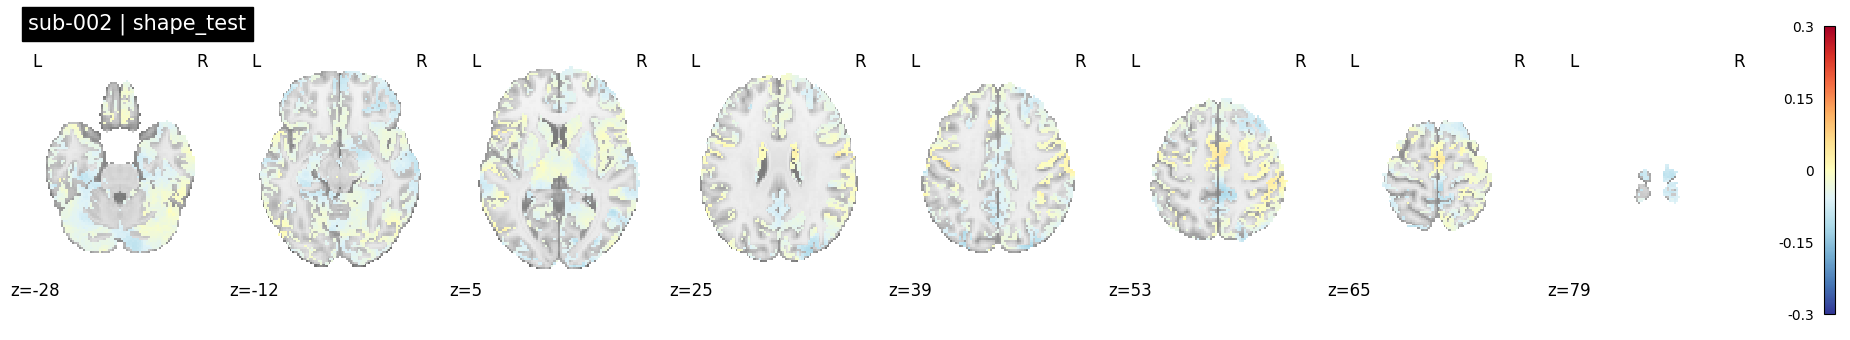

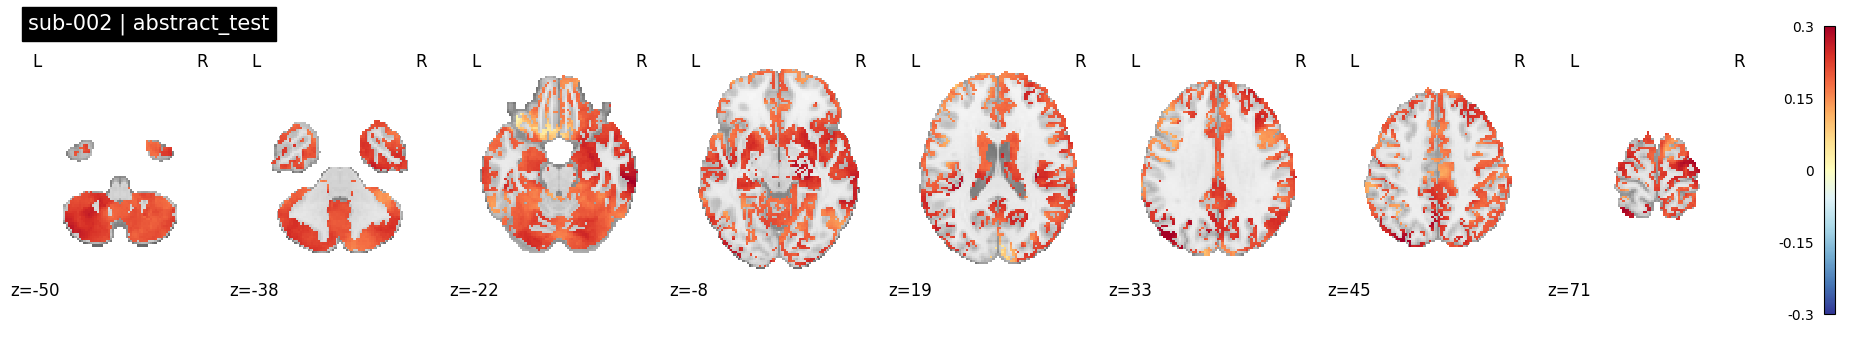

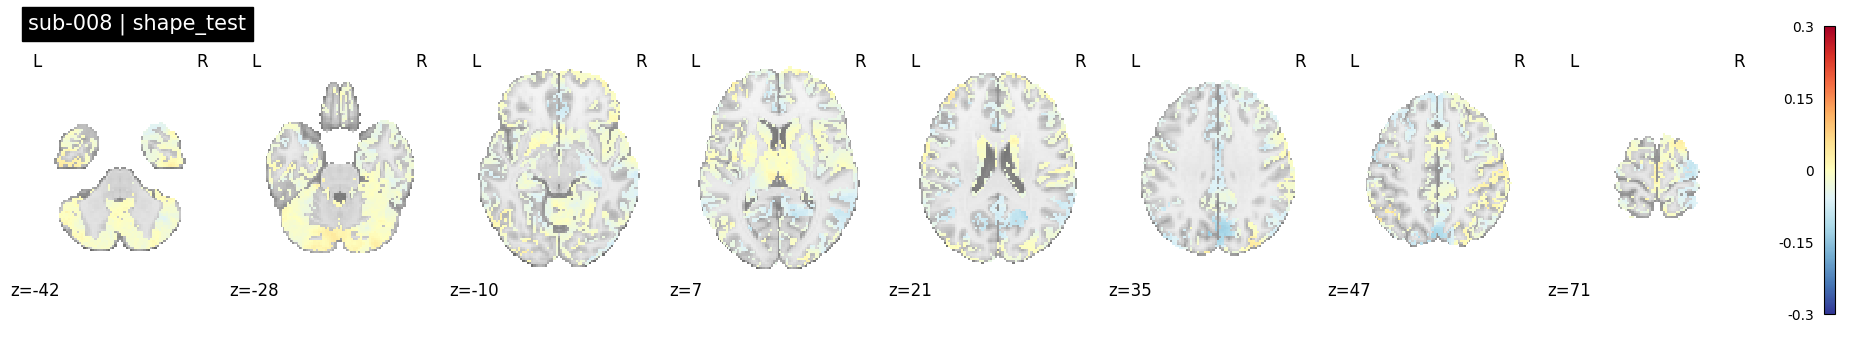

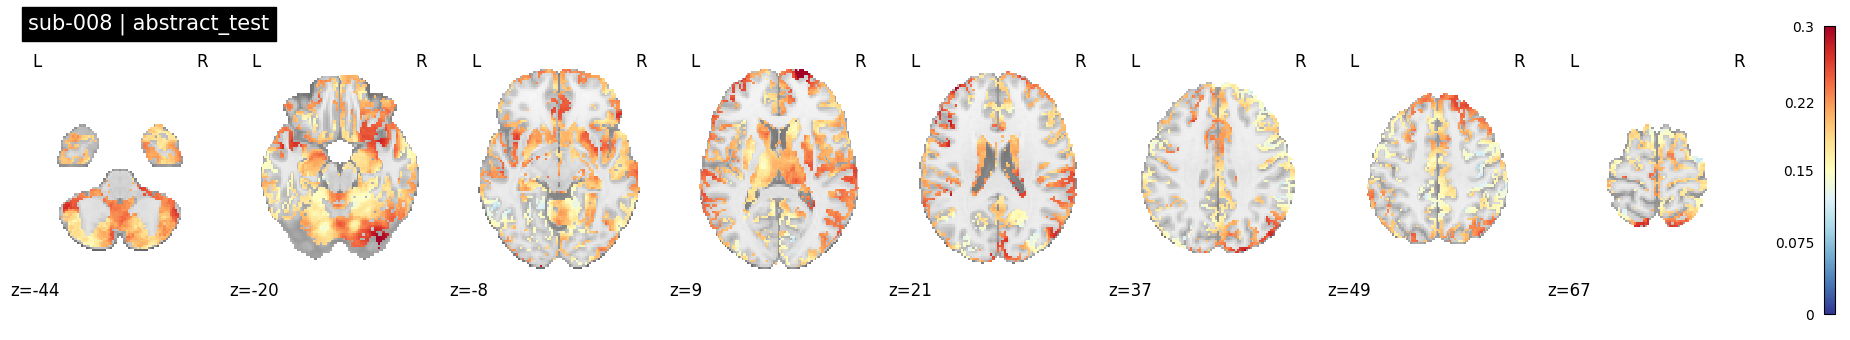

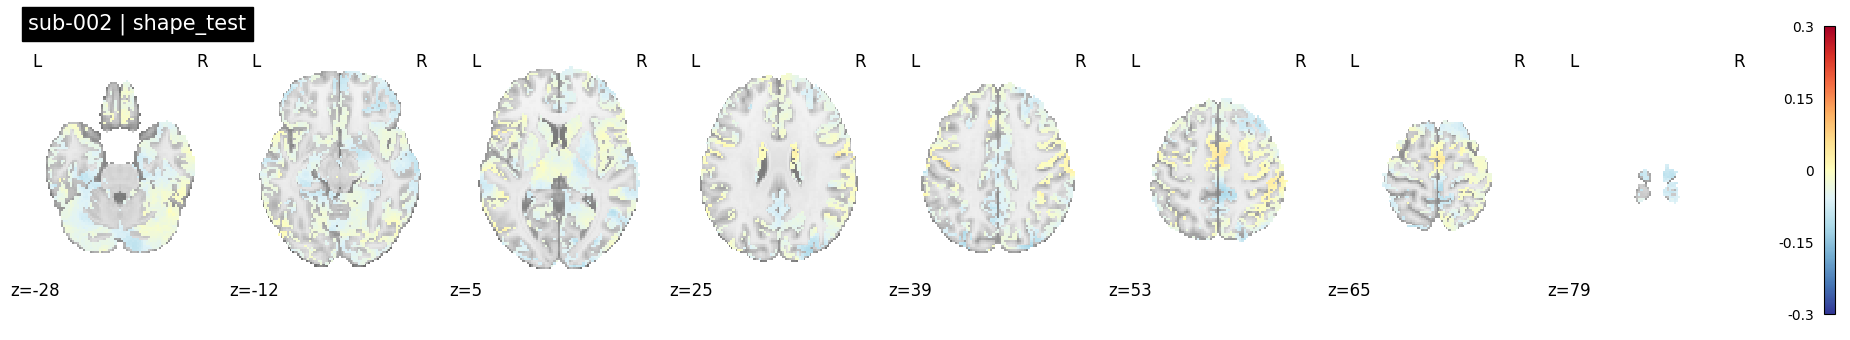

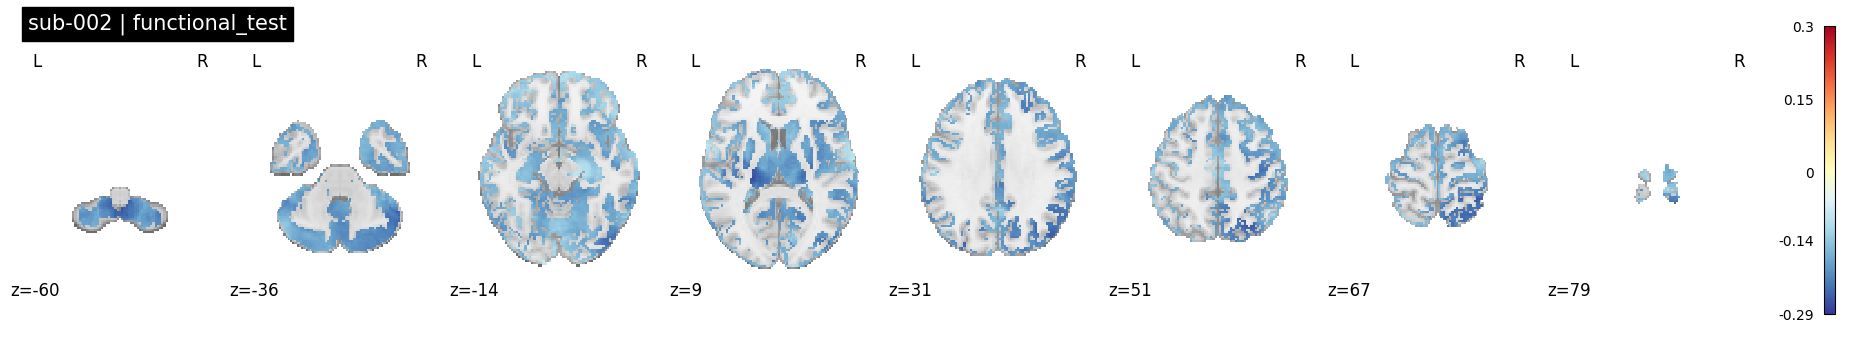

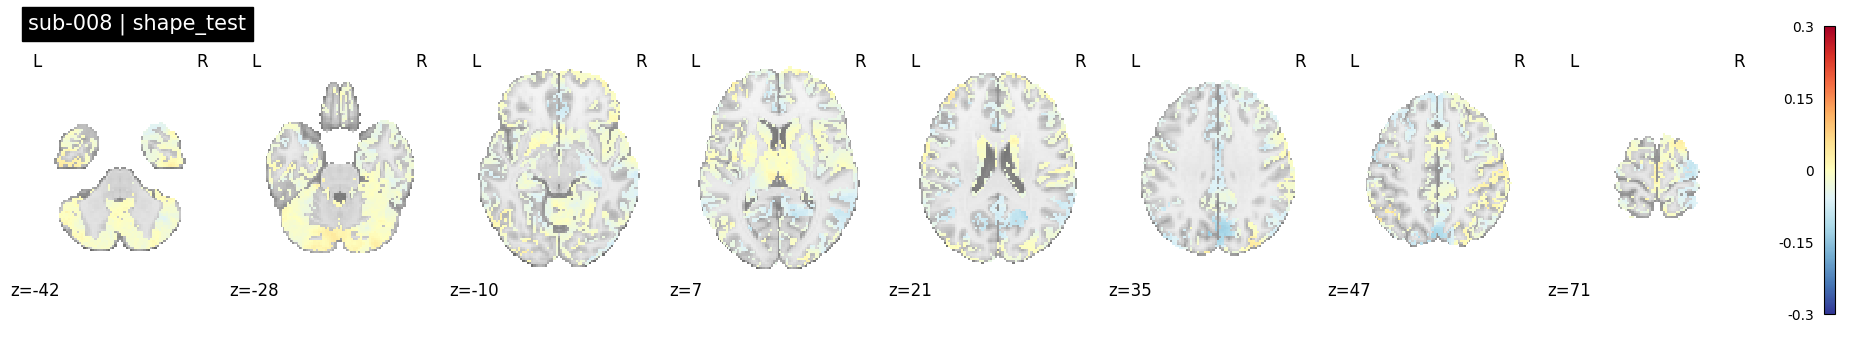

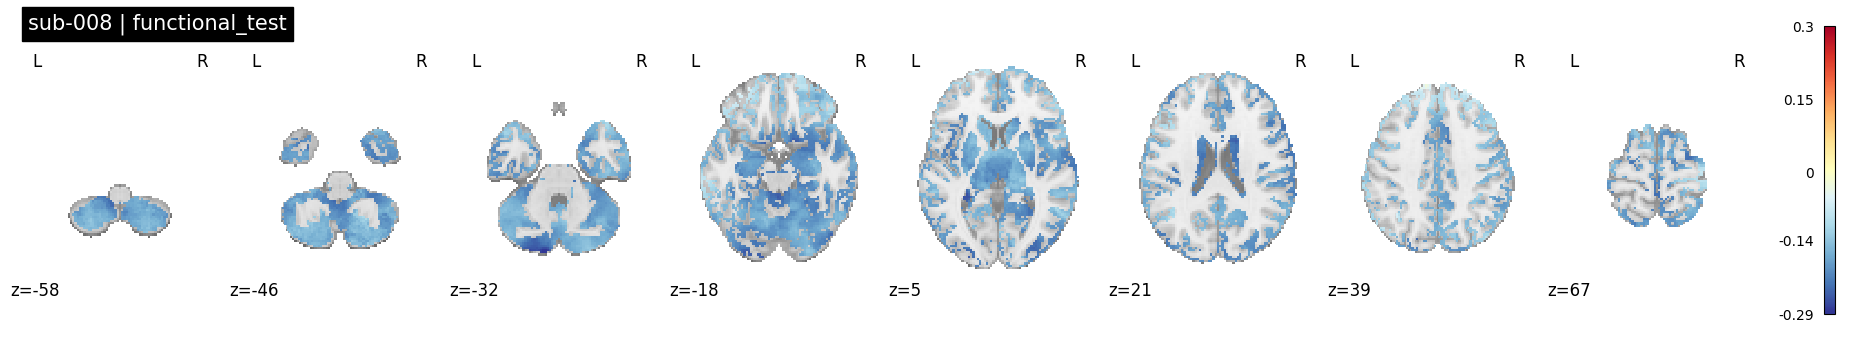

In [132]:
for i, model_path in enumerate(['model_rdms_test1.npz', 'model_rdms_test2.npz']):
    for subject in ['sub-002', 'sub-008']:
        npz        = np.load(os.path.join(results_dir, model_path), allow_pickle=True)
        model_names = [k for k in npz.files if k != 'conditions']

        for name in model_names:
            img = nib.load(os.path.join(results_dir,
                                        f'{subject}_searchlight_rho_{name}_{i}.nii.gz'))
            plotting.plot_stat_map(
                img,
                threshold    = 0.00,
                display_mode = 'z',
                cut_coords   = 8,
                colorbar     = True,
                cmap         = 'RdYlBu_r',
                vmax         = 0.3,
                title        = f'{subject} | {name}'
            )
            plt.savefig(os.path.join(results_dir,
                                    f'{subject}_searchlight_{name}_{i}.png'),
                        dpi=120, bbox_inches='tight')
            plt.show()

/tmp/ipykernel_1138068/330126801.py:12: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(


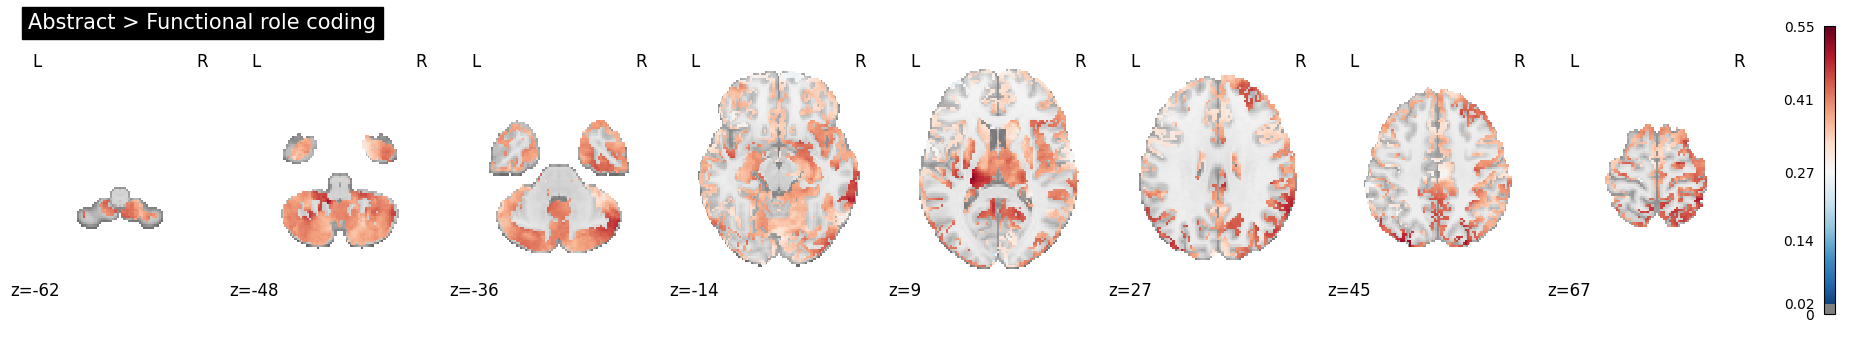

In [123]:
# Load RSA maps across subjects
rho_abstract   = nib.load(os.path.join(results_dir, 'sub-002_searchlight_rho_abstract_test.nii.gz')).get_fdata()
rho_functional = nib.load(os.path.join(results_dir, 'sub-002_searchlight_rho_functional_test.nii.gz')).get_fdata()

# At each voxel: which model fits better?
# Positive = abstract wins; negative = functional wins
difference_map = rho_abstract - rho_functional
winner_map = np.sign(difference_map)  # +1, -1, or 0

img_diff = nib.Nifti1Image(difference_map, affine)
img_diff.to_filename(os.path.join(results_dir, 'abstract_minus_functional.nii.gz'))
plotting.plot_stat_map(
    img_diff,
    threshold    = 0.02,
    display_mode = 'z',
    cut_coords   = 8,
    colorbar     = True,
    cmap         = 'RdBu_r',   # red = abstract wins, blue = functional wins
    title        = 'Abstract > Functional role coding'
)


MNI (-44, 36, 28) → voxel [26 84 53]
Sphere at (-44, 36, 28): 221 voxels within 12.0mm


/tmp/ipykernel_1492562/3283968244.py:91: UserWarning: kwargs['alpha']=0.7 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(sphere_img, cmap='autumn', alpha=0.7)


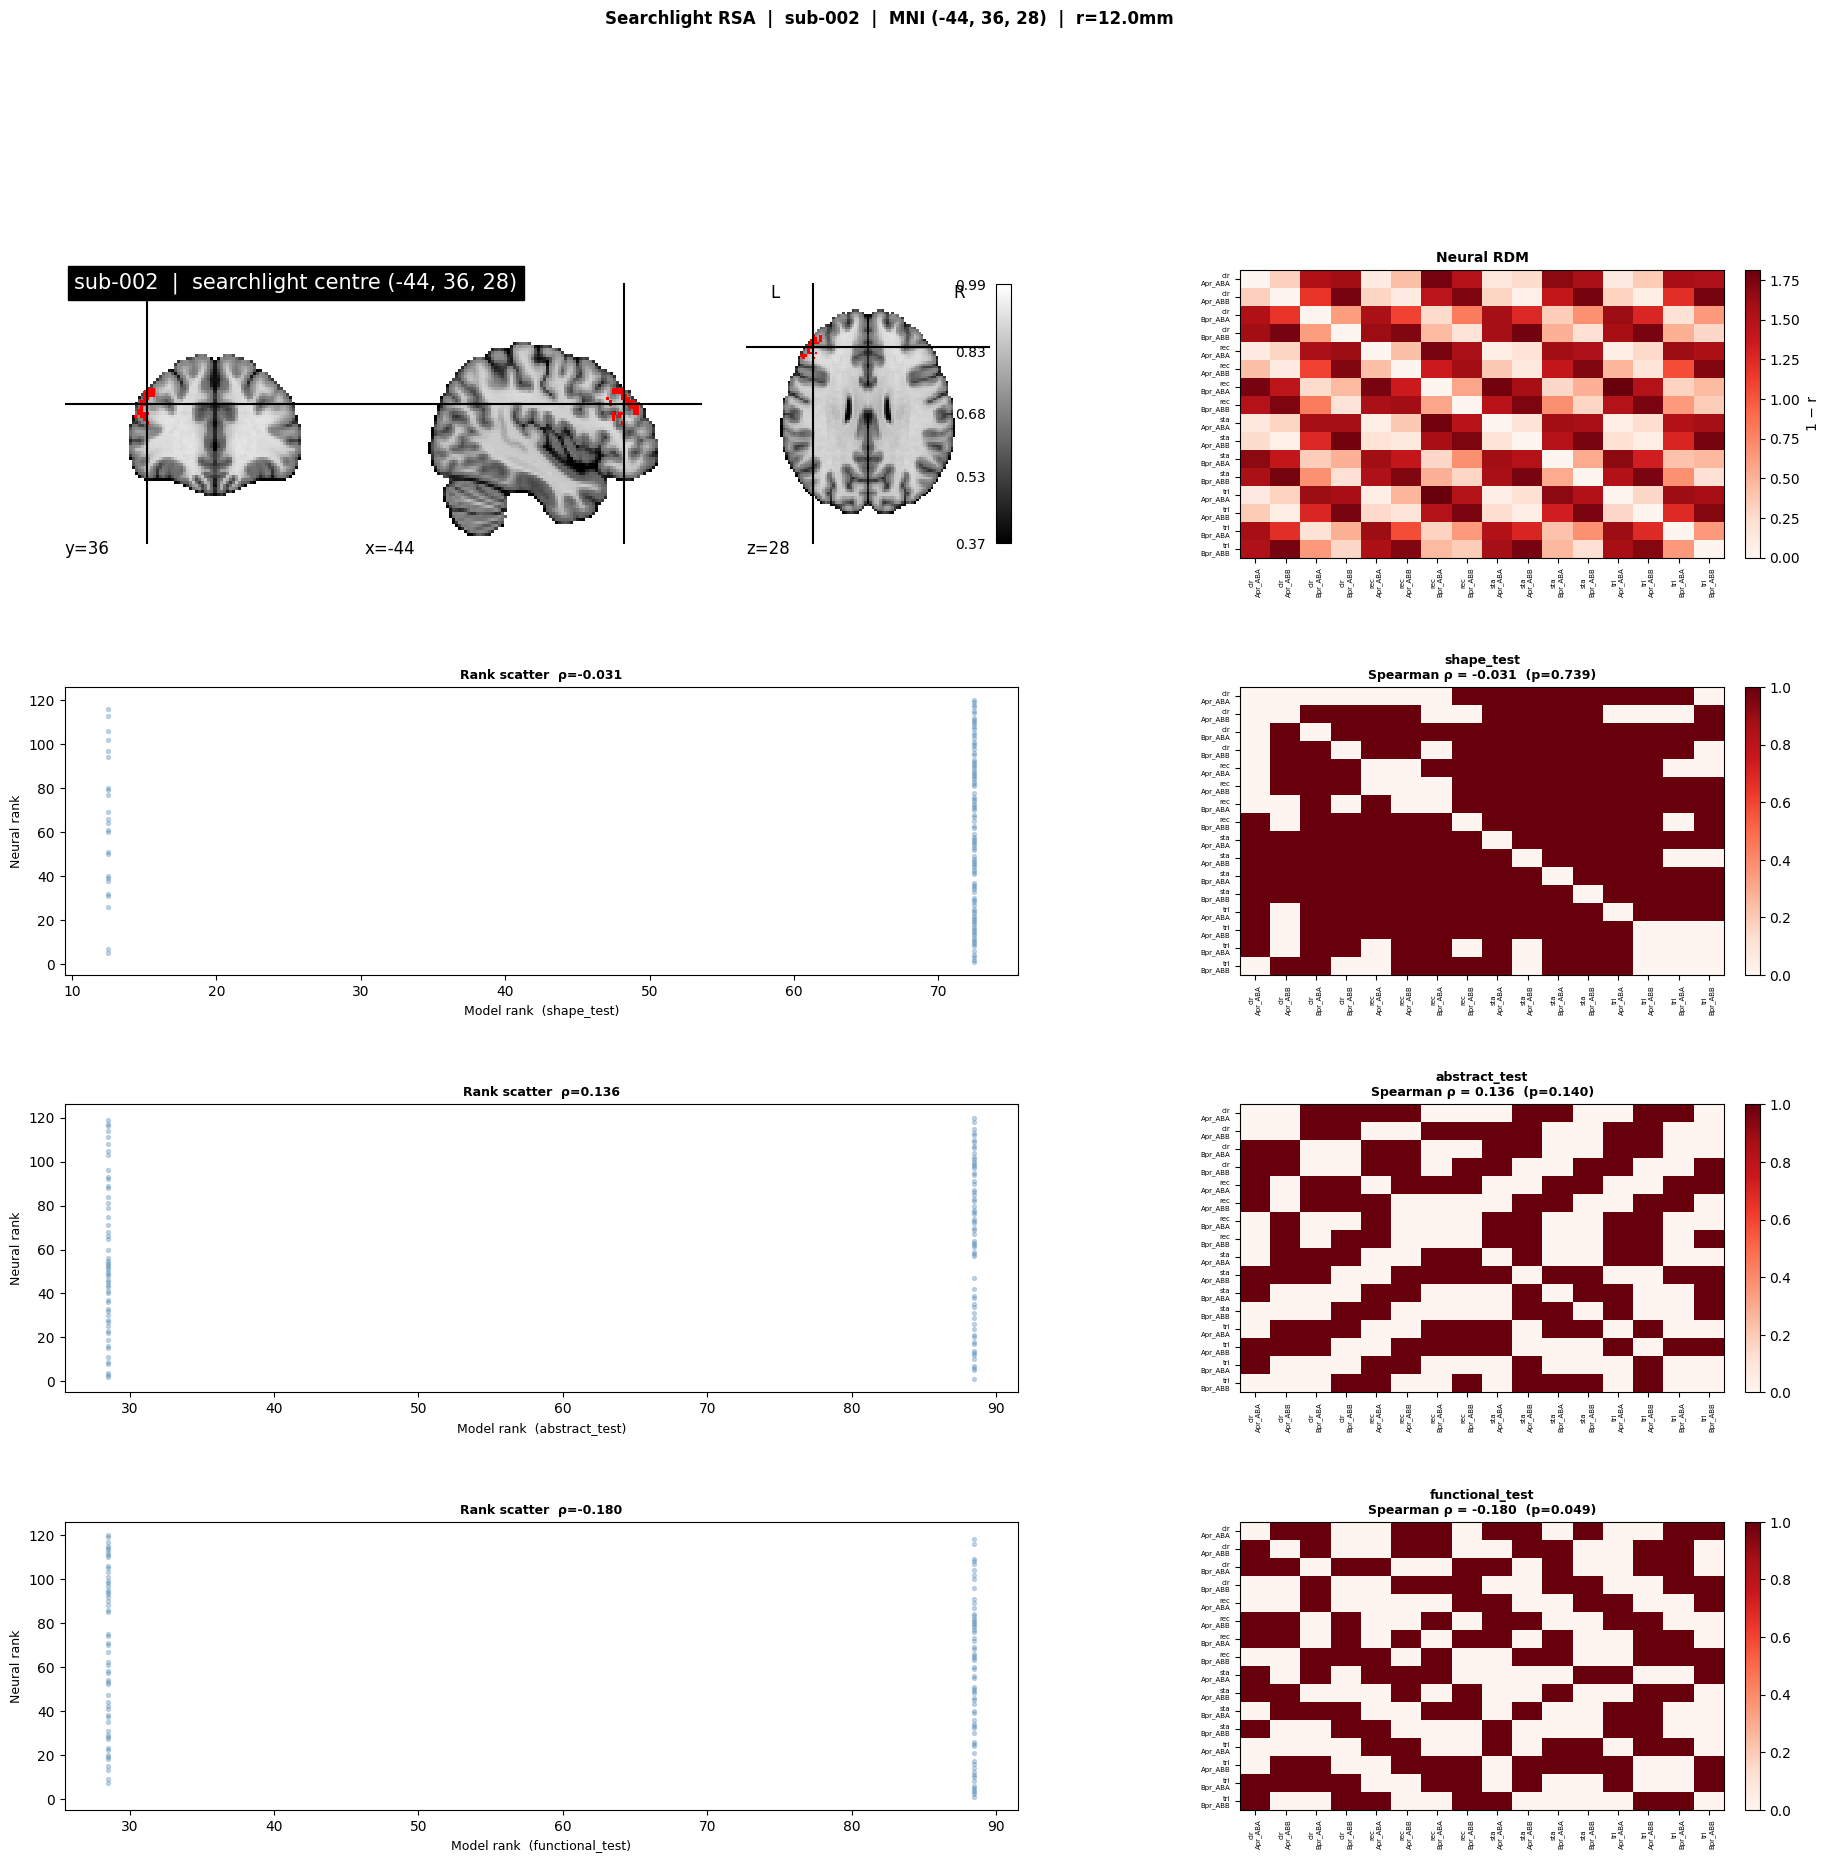

Saved: rsa_results/sub-002_rdm_probe_(-44, 36, 28).png


In [28]:
def get_lower_tri(rdm):
    """Handle both full matrix (n,n) and pre-vectorized (n*(n-1)/2,) inputs."""
    if rdm.ndim == 2:
        idx = np.tril_indices(rdm.shape[0], k=-1)
        return rdm[idx]
    return rdm   # already a vector
import matplotlib.gridspec as gridspec
# ── 0. Parameters — change these ─────────────────────────────────────────────
subject    = 'sub-002'
# MNI_COORD  = (0, -52, 28)   # MNI xyz in mm — posterior cingulate as default
MNI_COORD = (-44, 36, 28)  # left lateral prefrontal cortex — should show abstract coding
RADIUS_MM  = 12.0

# ── 1. Load data ──────────────────────────────────────────────────────────────
beta_4d    = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))

all_conditions = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
                              header=None)[0].tolist()[1:]
conditions     = [c for c in all_conditions if 'test' in parse_condition(c)['phase']]
test_indices   = [all_conditions.index(c) for c in conditions]

from nilearn.image import index_img
beta_4d  = index_img(beta_4d, test_indices)
beta_data = beta_4d.get_fdata()           # (x, y, z, 16)
affine    = beta_4d.affine
vox_size  = np.abs(np.diag(affine)[:3])
n_cond    = len(conditions)

# Load model RDMs for overlay
npz        = np.load(os.path.join(results_dir, 'model_rdms_test.npz'), allow_pickle=True)
model_rdms = {k: npz[k] for k in npz.files if k != 'conditions'}
# ── 2. Convert MNI coordinate → voxel index ───────────────────────────────────
def mni_to_vox(mni_coord, affine):
    """MNI mm → nearest voxel index."""
    inv_affine = np.linalg.inv(affine)
    vox = nib.affines.apply_affine(inv_affine, mni_coord)
    return np.round(vox).astype(int)


center_vox = mni_to_vox(MNI_COORD, affine)
print(f"MNI {MNI_COORD} → voxel {center_vox}")
# ── 3. Extract sphere and compute neural RDM ──────────────────────────────────
mask_data  = np.all(beta_data != 0, axis=-1)
vox_coords = np.array(np.where(mask_data)).T    # (n_vox, 3)

# Find in-mask voxels within radius
dists_mm     = np.sqrt(((vox_coords - center_vox)**2 * vox_size**2).sum(axis=1))
neighbor_idx = np.where(dists_mm <= RADIUS_MM)[0]
neighbor_vox = vox_coords[neighbor_idx]

print(f"Sphere at {MNI_COORD}: {len(neighbor_vox)} voxels within {RADIUS_MM}mm")

# Pattern matrix: (n_cond, n_neighbors)
patterns   = beta_data[neighbor_vox[:,0], neighbor_vox[:,1], neighbor_vox[:,2], :].T
neural_vec = pdist(patterns, metric='correlation')
neural_rdm = squareform(neural_vec)              # (n_cond, n_cond)

# Condition labels — shortened for display
short_labels = []
for c in conditions:
    p = parse_condition(c)
    rule = f"_{p['rule_type']}" if p['rule_type'] else ''
    short_labels.append(f"{p['shape'][:3]}\n{p['role'][:3]}{rule}")
# ── 4. Sphere indicator NIfTI for brain plot ──────────────────────────────────
# Build a small volume with 1s inside the sphere, for plotting the location
sphere_map            = np.zeros(beta_data.shape[:3])
sphere_map[neighbor_vox[:,0], neighbor_vox[:,1], neighbor_vox[:,2]] = 1.0
sphere_img            = nib.Nifti1Image(sphere_map, affine)
n_models = len(model_rdms)
fig      = plt.figure(figsize=(22, 5 + 5 * n_models))

# GridSpec: top row = brain + neural RDM; subsequent rows = model RDMs
gs = gridspec.GridSpec(
    1 + n_models, 2,
    width_ratios  = [1.8, 1],
    hspace        = 0.45,
    wspace        = 0.3
)

# ── Brain plot (top left) ──────────────────────────────────────────────────────
ax_brain = fig.add_subplot(gs[0, 0])
display  = plotting.plot_anat(
    axes        = ax_brain,
    display_mode= 'ortho',
    cut_coords  = MNI_COORD,
    annotate    = True,
    draw_cross  = True,
    dim         = -0.5,
    title       = f'{subject}  |  searchlight centre {MNI_COORD}'
)
display.add_overlay(sphere_img, cmap='autumn', alpha=0.7)

# ── Neural RDM (top right) ────────────────────────────────────────────────────
ax_rdm = fig.add_subplot(gs[0, 1])
im     = ax_rdm.imshow(neural_rdm, cmap='Reds', vmin=0,
                        interpolation='none', aspect='auto')
ax_rdm.set_xticks(range(n_cond))
ax_rdm.set_xticklabels(short_labels, fontsize=5, rotation=90)
ax_rdm.set_yticks(range(n_cond))
ax_rdm.set_yticklabels(short_labels, fontsize=5)
ax_rdm.set_title('Neural RDM', fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax_rdm, fraction=0.046, pad=0.04, label='1 − r')

# ── Model RDMs below, with Spearman rho in title ─────────────────────────────
for row, (name, rdm) in enumerate(model_rdms.items()):

    from scipy.stats import spearmanr

    model_vec = get_lower_tri(rdm)          # always (120,) regardless of storage format
    rho_val, p_val = spearmanr(neural_vec, model_vec)

    # RDM panel — need full matrix for imshow
    rdm_full = squareform(model_vec)        # (16, 16) for display

    ax_m = fig.add_subplot(gs[1 + row, 1])
    im_m = ax_m.imshow(rdm_full, cmap='Reds', vmin=0, vmax=1,
                        interpolation='none', aspect='auto')
    ax_m.set_xticks(range(n_cond))
    ax_m.set_xticklabels(short_labels, fontsize=5, rotation=90)
    ax_m.set_yticks(range(n_cond))
    ax_m.set_yticklabels(short_labels, fontsize=5)
    ax_m.set_title(f'{name}\nSpearman ρ = {rho_val:.3f}  (p={p_val:.3f})',
                   fontsize=9, fontweight='bold')
    plt.colorbar(im_m, ax=ax_m, fraction=0.046, pad=0.04)

    # Scatter: neural vec vs model vec (rank space) — left column
    ax_s = fig.add_subplot(gs[1 + row, 0])
    from scipy.stats import rankdata
    # ax_s.scatter(rankdata(squareform(rdm)[np.tril_indices(n_cond, k=-1)]),
    #              rankdata(neural_vec),
    #              alpha=0.3, s=8, color='steelblue', rasterized=True)
    ax_s.scatter(rankdata(model_vec),
                 rankdata(neural_vec),
                 alpha=0.3, s=8, color='steelblue', rasterized=True)
    ax_s.set_xlabel(f'Model rank  ({name})', fontsize=9)
    ax_s.set_ylabel('Neural rank', fontsize=9)
    ax_s.set_title(f'Rank scatter  ρ={rho_val:.3f}', fontsize=9, fontweight='bold')

plt.suptitle(f'Searchlight RSA  |  {subject}  |  MNI {MNI_COORD}  |  r={RADIUS_MM}mm',
             fontsize=12, fontweight='bold', y=1.01)

out_path = os.path.join(results_dir, f'{subject}_rdm_probe_{MNI_COORD}.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

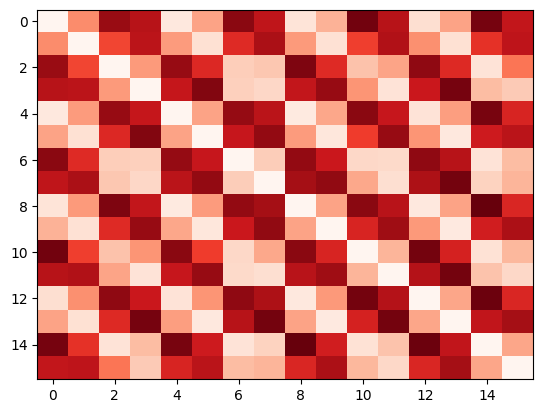

In [26]:
plt.imshow(neural_rdm, cmap='Reds', vmin=0, aspect='auto')

In [138]:
rdm.shape

(16, 16)

# Searchlight regression

In [7]:
# ── 0. Check VIFs on model RDM vectors before committing ─────────────────────
from numpy.linalg import lstsq
from scipy.spatial.distance import squareform
from scipy.stats import rankdata

def compute_vif(model_vecs, model_names):
    X = np.column_stack([rankdata(model_vecs[n]) for n in model_names])
    vifs = {}
    for k, name in enumerate(model_names):
        y_k    = X[:, k]
        X_rest = np.delete(X, k, axis=1)
        X_rest = np.hstack([X_rest, np.ones((len(X_rest), 1))])
        betas, _, _, _ = lstsq(X_rest, y_k, rcond=None)
        y_pred = X_rest @ betas
        ss_res = ((y_k - y_pred)**2).sum()
        ss_tot = ((y_k - y_k.mean())**2).sum()
        r2     = 1 - ss_res / ss_tot
        vifs[name] = 1 / (1 - r2) if r2 < 1.0 else np.inf
    return vifs

npz        = np.load(os.path.join(results_dir, 'model_rdms_test.npz'), allow_pickle=True)
model_rdms = {k: npz[k] for k in npz.files if k != 'conditions'}

def get_lower_tri(rdm):
    if rdm.ndim == 2:
        # return rdm[np.tril_indices(rdm.shape[0], k=-1)]
        return squareform(rdm) # this is row-major upper triangular!
    return rdm

model_vecs  = {name: get_lower_tri(rdm) for name, rdm in model_rdms.items()}
model_names = list(model_vecs.keys())

vifs = compute_vif(model_vecs, model_names)
print("VIFs:")
for name, v in vifs.items():
    flag = "  ← WARNING" if v > 5 else ""
    print(f"  {name:25s}: {v:.3f}{flag}")

VIFs:
  shape_test               : 1.040
  abstract_test            : 1.027
  functional_test          : 1.027


In [8]:
model_rdms

{'shape_test': array([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1.,

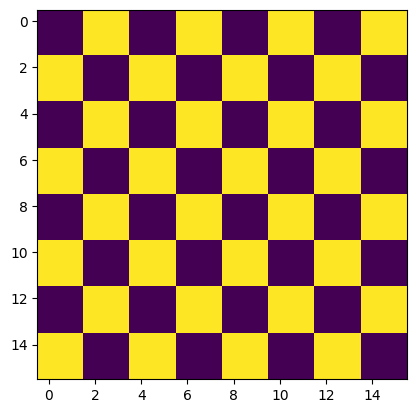

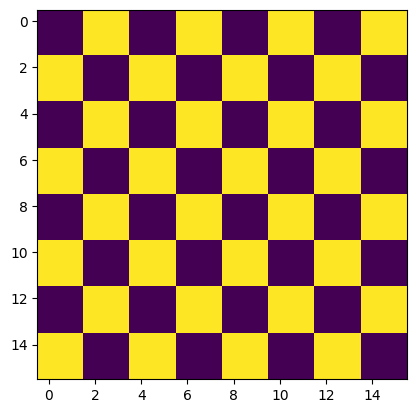

In [9]:
plt.imshow(squareform(model_vecs['abstract_test']))
plt.show()
plt.imshow(model_rdms['abstract_test'])

In [10]:
# ── 1. Partial RSA searchlight function ──────────────────────────────────────
# Rank-based OLS — equivalent to partial Spearman
# Returns one beta per model per voxel (unique variance after partialling others)

def partial_searchlight_one_voxel(center_idx, beta_data, vox_coords, vox_size,
                                   model_vecs, model_names, n_cond, radius_mm):
    try:
        center_vox   = vox_coords[center_idx]
        dists_mm     = np.sqrt(((vox_coords - center_vox)**2 * vox_size**2).sum(axis=1))
        neighbor_idx = np.where(dists_mm <= radius_mm)[0]

        if len(neighbor_idx) < n_cond:
            return np.full(len(model_names), np.nan)

        nv         = vox_coords[neighbor_idx]
        patterns   = beta_data[nv[:,0], nv[:,1], nv[:,2], :].T   # (n_cond, n_neighbors)
        neural_vec = pdist(patterns, metric='correlation')         # (120,)

        # Rank-transform everything — makes this Spearman-equivalent partial regression
        y = (neural_vec).reshape(-1, 1)                    # (120, 1)
        X = np.column_stack([(model_vecs[n])
                             for n in model_names])                 # (120, n_models)
        X = np.hstack([X, np.ones((X.shape[0], 1))])              # add intercept

        betas, _, _, _ = lstsq(X, y, rcond=None)                  # (n_models+1, 1)
        return betas[:-1, 0]                                       # drop intercept → (n_models,)

    except Exception:
        return np.full(len(model_names), np.nan)

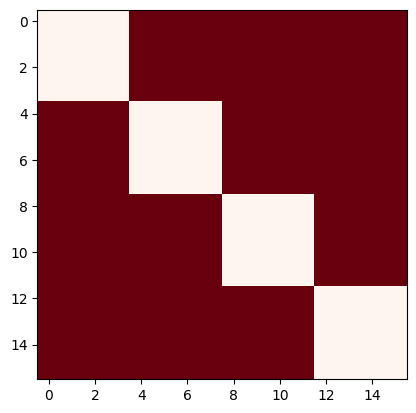

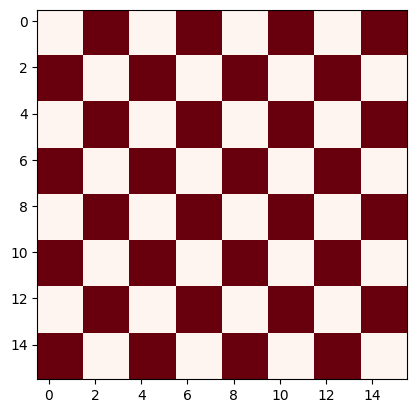

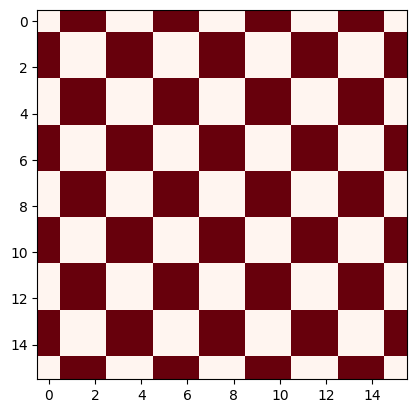

In [11]:
design_matrix = np.column_stack([(model_vecs[n]) for n in model_names])
for i in range(3): 

    plt.imshow(squareform(design_matrix[:, i]), cmap='Reds', vmin=0)
    plt.show()

In [20]:
# ── 2. Run partial searchlight per subject ────────────────────────────────────
from joblib import Parallel, delayed
from nilearn.image import index_img

RADIUS_MM = 12.0

for subject in ['sub-002', 'sub-008']:
    print(f'\n=== {subject} ===')

    beta_4d        = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))
    all_conditions = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
                                  header=None)[0].tolist()[1:]
    conditions     = [c for c in all_conditions if 'test' in parse_condition(c)['phase']]
    test_indices   = [all_conditions.index(c) for c in conditions]
    beta_4d        = index_img(beta_4d, test_indices)
    n_cond         = len(conditions)

    beta_data  = beta_4d.get_fdata()
    affine     = beta_4d.affine
    vox_size   = np.abs(np.diag(affine)[:3])
    mask_data  = np.all(beta_data != 0, axis=-1)
    vox_coords = np.array(np.where(mask_data)).T
    n_vox      = len(vox_coords)

    expected_vec_len = n_cond * (n_cond - 1) // 2
    print(f"N conditions: {n_cond}  |  RDM vec length: {expected_vec_len}")
    print(f"Searchlight centers: {n_vox}")

    print(f"Launching partial RSA searchlight (radius={RADIUS_MM}mm) ...")
    results_list = Parallel(n_jobs=-1, verbose=5)(
        delayed(partial_searchlight_one_voxel)(
            i, beta_data, vox_coords, vox_size,
            model_vecs, model_names, n_cond, RADIUS_MM
        )
        for i in range(n_vox)
    )

    # Sanitize
    n_models = len(model_names)
    results_clean = []
    for r in results_list:
        r = np.asarray(r, dtype=float)
        results_clean.append(r if r.shape == (n_models,) else np.full(n_models, np.nan))
    results_arr = np.array(results_clean)    # (n_vox, n_models)
    print(f"Done. Shape: {results_arr.shape}")

    # Save one NIfTI per model
    for m_idx, name in enumerate(model_names):
        beta_map = np.full(beta_data.shape[:3], np.nan)
        beta_map[vox_coords[:,0],
                 vox_coords[:,1],
                 vox_coords[:,2]] = results_arr[:, m_idx]

        img      = nib.Nifti1Image(beta_map, affine)
        out_path = os.path.join(results_dir,
                                f'{subject}_partial_rsa_beta_{name}.nii.gz')
        img.to_filename(out_path)
        print(f"Saved: {out_path}  |  "
              f"mean β: {np.nanmean(beta_map):.4f}  |  "
              f"max β:  {np.nanmax(beta_map):.4f}")


=== sub-002 ===
N conditions: 16  |  RDM vec length: 120
Searchlight centers: 85818
Launching partial RSA searchlight (radius=12.0mm) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 612 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 2668 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 6412 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 10732 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 15628 tasks      | elapsed:    5.3s
Process LokyProcess-20:
Process LokyProcess-27:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/people/yl0124/.conda/envs/neu502b/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/people/yl0124/.conda/envs/neu502b/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/people/yl0124/.conda/envs/neu502b/lib/python3.12/site-packages/jobli

KeyboardInterrupt: 

/tmp/ipykernel_3222262/1098908443.py:8: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(


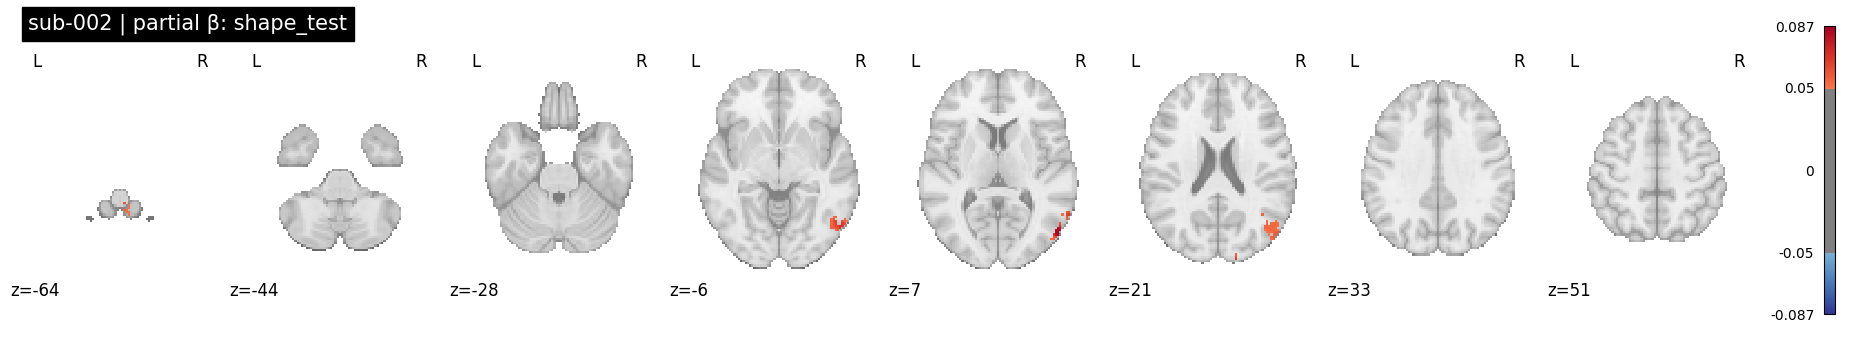

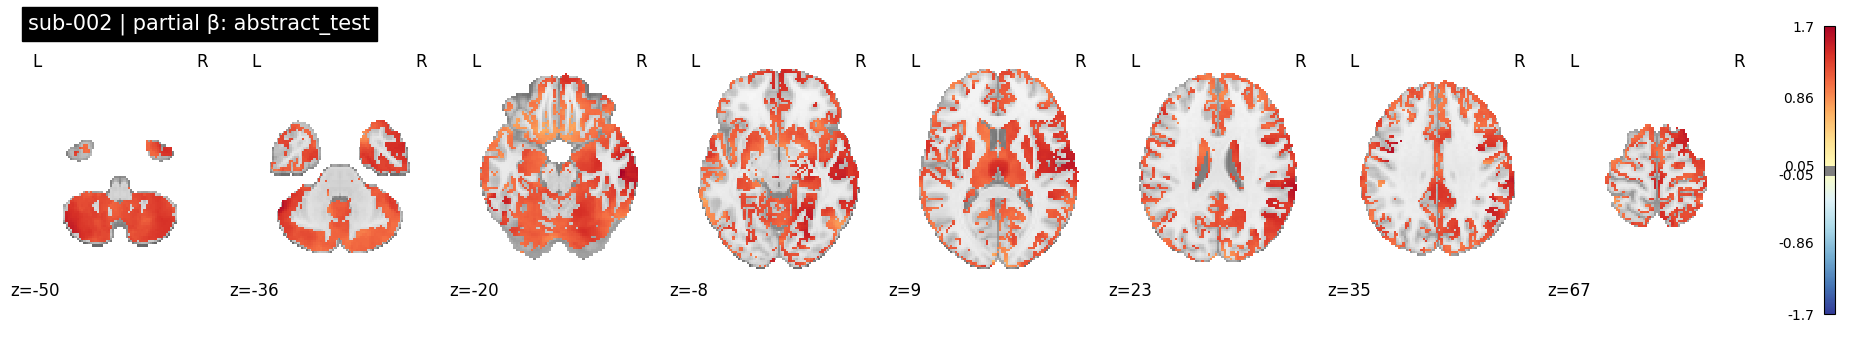

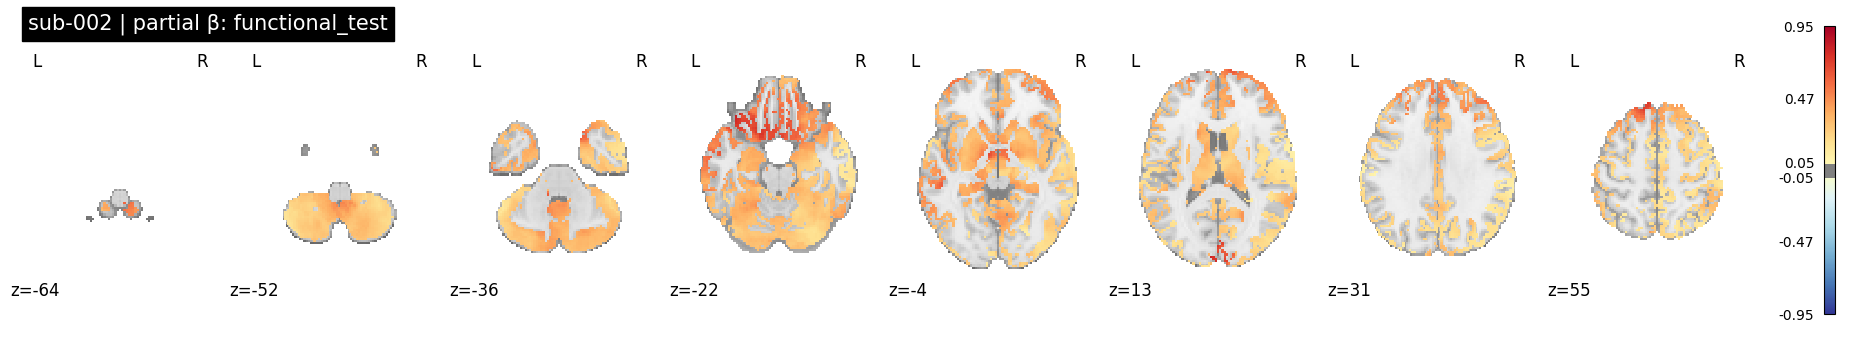

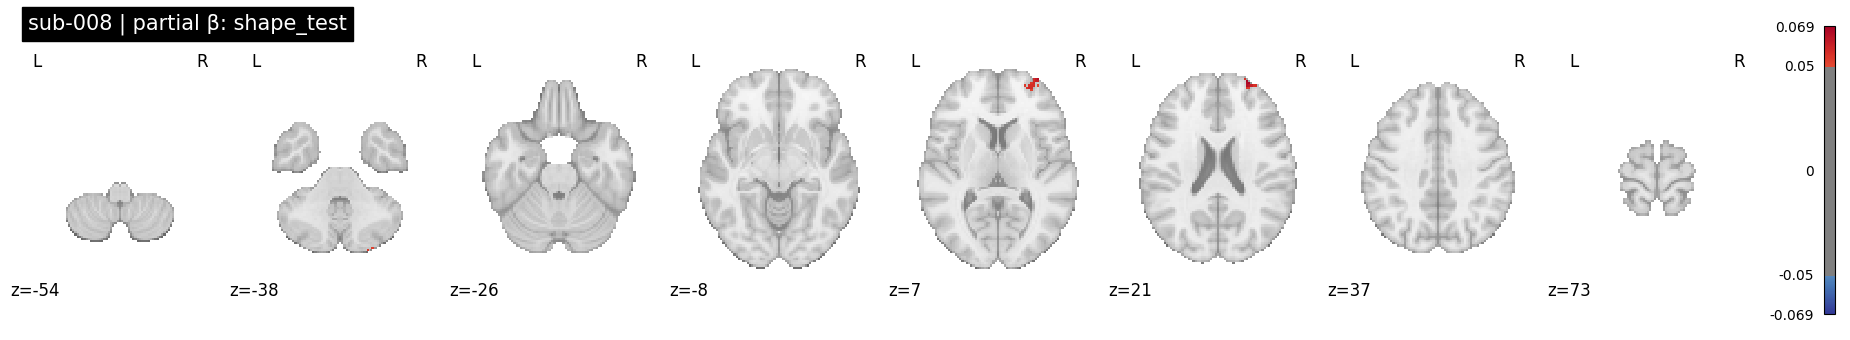

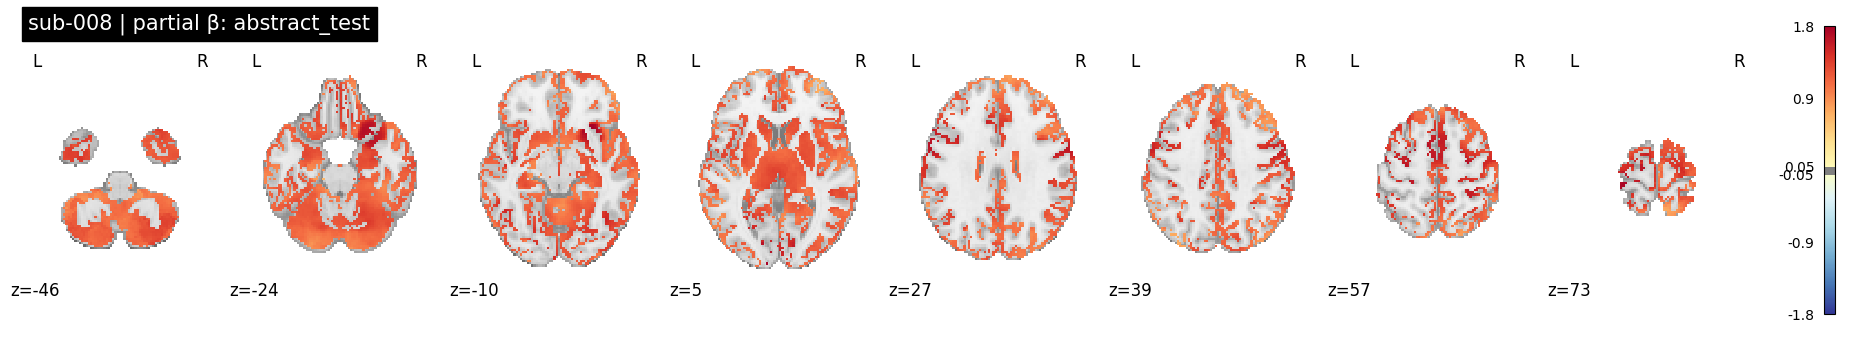

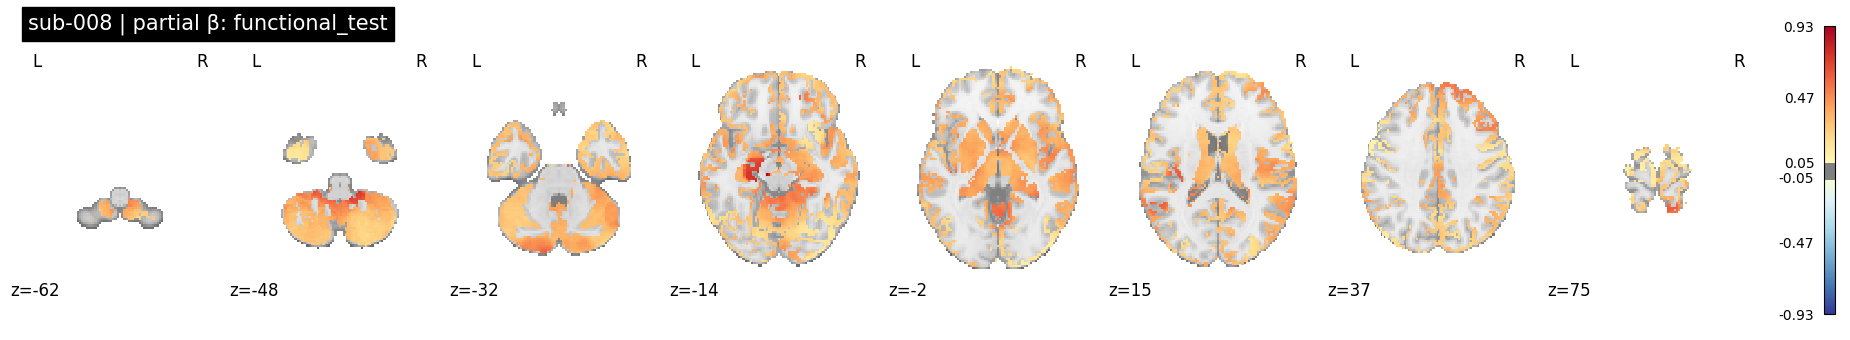

In [21]:
# ── 3. Visualize partial beta maps ────────────────────────────────────────────
from nilearn import plotting

for subject in ['sub-002', 'sub-008']:
    for name in model_names:
        img = nib.load(os.path.join(results_dir,
                                    f'{subject}_partial_rsa_beta_{name}.nii.gz'))
        plotting.plot_stat_map(
            img,
            threshold    = 0.05,
            display_mode = 'z',
            cut_coords   = 8,
            colorbar     = True,
            cmap         = 'RdYlBu_r',
            title        = f'{subject} | partial β: {name}',
            vmax = np.nanmax(np.abs(img.get_fdata())),
            vmin = -np.nanmax(np.abs(img.get_fdata())),
        )
        plt.savefig(os.path.join(results_dir,
                                 f'{subject}_partial_rsa_{name}.png'),
                    dpi=120, bbox_inches='tight')
        plt.show()

/tmp/ipykernel_3222262/3002829330.py:15: UserWarning: empty mask
  plotting.plot_stat_map(


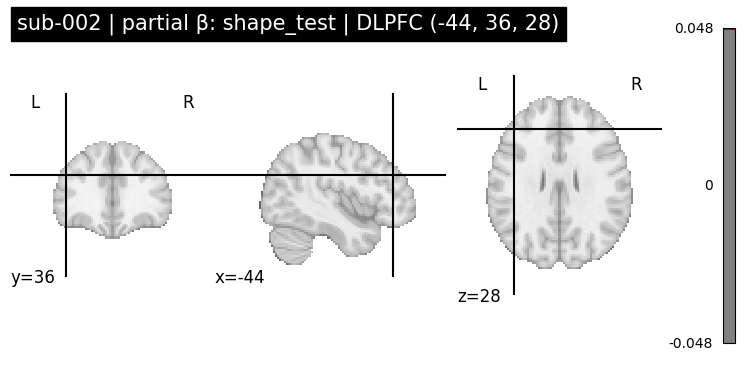

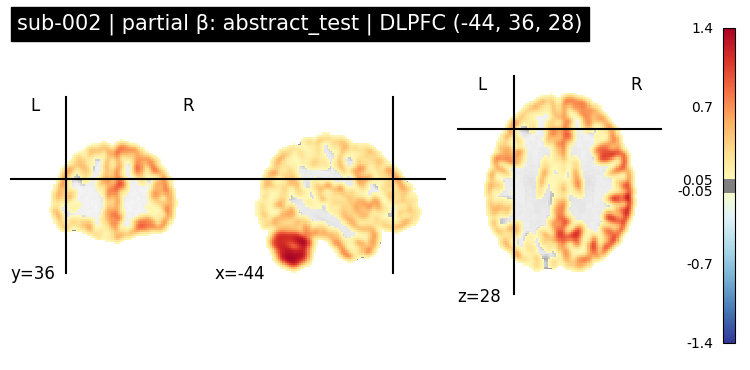

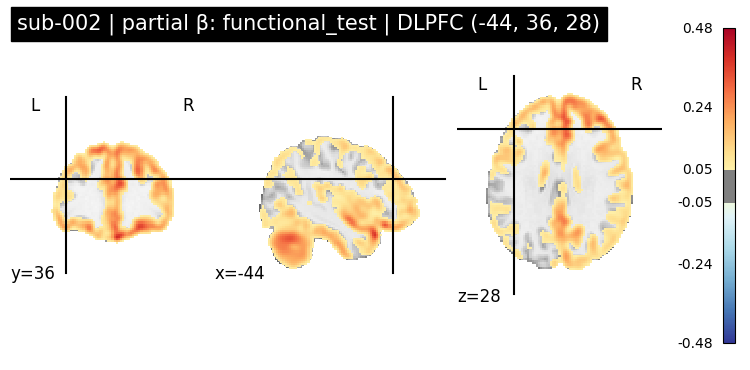

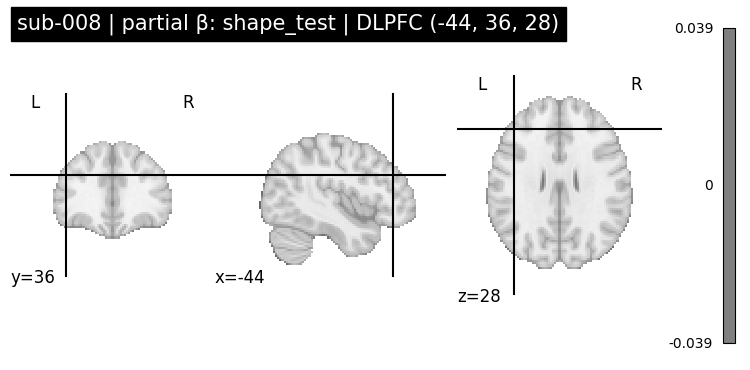

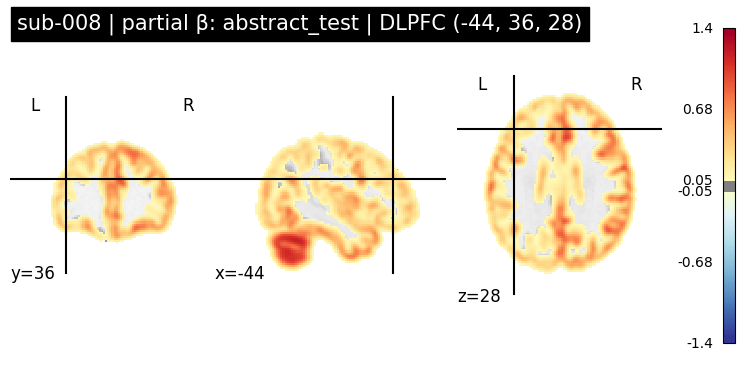

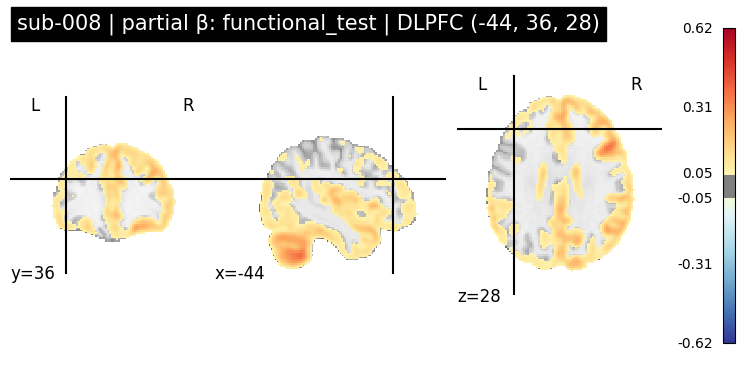

In [23]:


from nilearn import plotting, image

MNI_COORD = (-44, 36, 28)

for subject in ['sub-002', 'sub-008']:
    for name in model_names:
        img = nib.load(os.path.join(results_dir,
                                    f'{subject}_partial_rsa_beta_{name}.nii.gz'))

        # Smooth to reveal local structure around the coordinate
        img_smooth = image.smooth_img(img, fwhm=6)

        vmax = np.nanmax(np.abs(img_smooth.get_fdata()))

        plotting.plot_stat_map(
            img_smooth,
            threshold    = 0.05,
            display_mode = 'ortho',          # ortho centers on coordinate
            cut_coords   = MNI_COORD,        # center on DLPFC
            colorbar     = True,
            cmap         = 'RdYlBu_r',
            vmax         = vmax,
            vmin         = -vmax,
            title        = f'{subject} | partial β: {name} | DLPFC {MNI_COORD}'
        )
        plt.savefig(os.path.join(results_dir,
                                 f'{subject}_partial_rsa_{name}_dlpfc.png'),
                    dpi=120, bbox_inches='tight')
        plt.show()

In [13]:
# ── 4. Probe a specific coordinate — partial betas + scatter ─────────────────
MNI_COORD = (-44, 36, 28)   # left DLPFC

subject   = 'sub-002'
beta_4d   = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))
all_conditions = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
                              header=None)[0].tolist()[1:]
conditions     = [c for c in all_conditions if 'test' in parse_condition(c)['phase']]
test_indices   = [all_conditions.index(c) for c in conditions]
beta_4d        = index_img(beta_4d, test_indices)
beta_data      = beta_4d.get_fdata()
affine         = beta_4d.affine
vox_size       = np.abs(np.diag(affine)[:3])
mask_data      = np.all(beta_data != 0, axis=-1)
vox_coords     = np.array(np.where(mask_data)).T
n_cond         = len(conditions)

center_vox   = mni_to_vox(MNI_COORD, affine)
dists_mm     = np.sqrt(((vox_coords - center_vox)**2 * vox_size**2).sum(axis=1))
neighbor_idx = np.where(dists_mm <= RADIUS_MM)[0]
neighbor_vox = vox_coords[neighbor_idx]
patterns     = beta_data[neighbor_vox[:,0], neighbor_vox[:,1], neighbor_vox[:,2], :].T
neural_vec   = pdist(patterns, metric='correlation')

# Partial regression at this coordinate
y = rankdata(neural_vec).reshape(-1, 1)
X = np.column_stack([rankdata(model_vecs[n]) for n in model_names])
X_int = np.hstack([X, np.ones((X.shape[0], 1))])
betas_probe, _, _, _ = lstsq(X_int, y, rcond=None)
partial_betas = betas_probe[:-1, 0]

# Compare simple vs partial
from scipy.stats import spearmanr
print(f"\nCoordinate {MNI_COORD}  ({len(neighbor_vox)} voxels in sphere)\n")
print(f"{'Model':<25} {'Simple ρ':>10} {'Partial β':>12}")
print("-" * 50)
for i, name in enumerate(model_names):
    simple_rho, _ = spearmanr(neural_vec, model_vecs[name])
    print(f"{name:<25} {simple_rho:>10.4f} {partial_betas[i]:>12.4f}")

NameError: name 'parse_condition' is not defined

In [12]:
def plot_rank_neural_rdm(neural_vec, conditions, title='Ranked Neural RDM', ax=None):
    """
    Plot the neural RDM after rank-transforming its lower triangle entries.
    
    Parameters
    ----------
    neural_vec  : (n*(n-1)/2,) array — lower triangle of neural RDM (from pdist)
    conditions  : list of condition label strings
    title       : plot title
    ax          : matplotlib axis (if None, creates new figure)
    """
    from scipy.stats import rankdata

    n_cond = len(conditions)

    # Rank-transform the lower triangle, then reconstruct full matrix
    ranked_vec = rankdata(neural_vec)                    # (120,) — ranks 1..120
    ranked_rdm = squareform(ranked_vec)                  # (n_cond, n_cond) symmetric
    np.fill_diagonal(ranked_rdm, 0)                      # diagonal = 0 by convention

    short_labels = []
    for c in conditions:
        p = parse_condition(c)
        rule = f"_{p['rule_type']}" if p['rule_type'] else ''
        short_labels.append(f"{p['shape'][:3]}\n{p['role'][:3]}{rule}")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(ranked_rdm, cmap='Reds', interpolation='none', aspect='auto')
    ax.set_xticks(range(n_cond))
    ax.set_xticklabels(short_labels, fontsize=5, rotation=90)
    ax.set_yticks(range(n_cond))
    ax.set_yticklabels(short_labels, fontsize=5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='rank (low = similar)')

    return ax

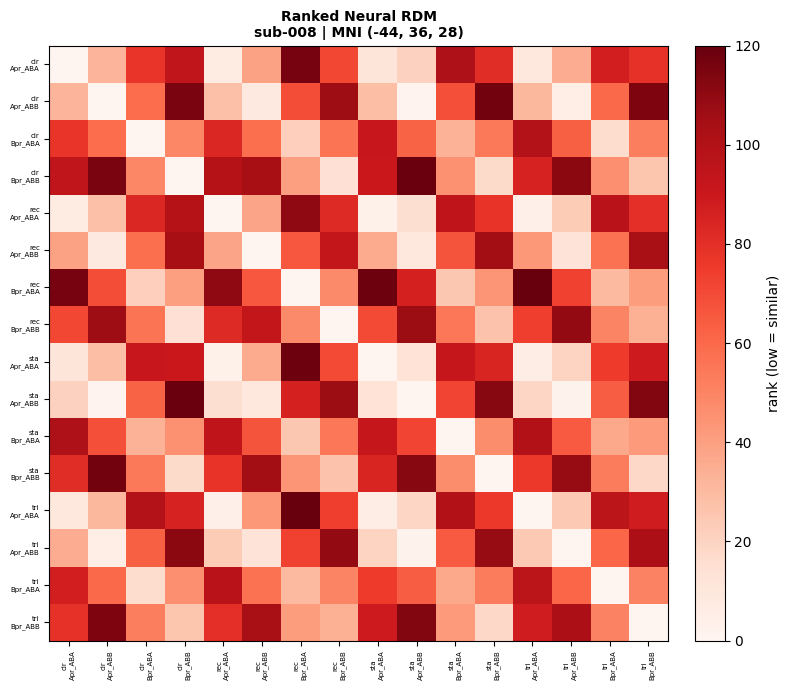

In [38]:
# Usage — probe a coordinate and plot ranked RDM
MNI_COORD  = (-44, 36, 28)
center_vox = mni_to_vox(MNI_COORD, affine)

dists_mm     = np.sqrt(((vox_coords - center_vox)**2 * vox_size**2).sum(axis=1))
neighbor_idx = np.where(dists_mm <= RADIUS_MM)[0]
neighbor_vox = vox_coords[neighbor_idx]
patterns     = beta_data[neighbor_vox[:,0], neighbor_vox[:,1], neighbor_vox[:,2], :].T
neural_vec   = pdist(patterns, metric='correlation')

plot_rank_neural_rdm(neural_vec, conditions,
                     title=f'Ranked Neural RDM\n{subject} | MNI {MNI_COORD}')
plt.tight_layout()
plt.show()

In [51]:
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.image import index_img
from numpy.linalg import lstsq
import os

# ── 0. Load betas and conditions ──────────────────────────────────────────────
subject        = 'sub-002'
all_conditions = pd.read_csv(os.path.join(results_dir, f'{subject}_condition_labels.csv'),
                              header=None)[0].tolist()[1:]
conditions     = [c for c in all_conditions if 'test' in parse_condition(c)['phase']]
test_indices   = [all_conditions.index(c) for c in conditions]

beta_4d   = nib.load(os.path.join(results_dir, f'{subject}_beta_4d.nii.gz'))
beta_4d   = index_img(beta_4d, test_indices)
beta_data = beta_4d.get_fdata()          # (x, y, z, 16)
affine    = beta_4d.affine
n_cond    = len(conditions)

meta_test = pd.DataFrame([parse_condition(c) for c in conditions], index=conditions)
meta_test['repeater'] = meta_test.apply(
    lambda r: r['role'] == 'Aprime' if r['rule_type'] == 'ABA' else r['role'] == 'Bprime',
    axis=1
)

In [52]:
# ── 1. Build condition-level design matrix X ∈ R^(16 × n_regressors) ─────────
# Each row = one condition; each column = one representational dimension
# Regression: beta_v (16,) = X @ gamma_v (n_regressors,) + epsilon

regressors = {}

# Shape — one-hot per shape (4 columns), mean-centered
for shape in ['circle', 'rectangle', 'star', 'triangle']:
    regressors[f'shape_{shape}'] = (meta_test['shape'] == shape).astype(float).values

# Abstract role: +1 = Aprime family, -1 = Bprime family
regressors['abstract'] = np.where(meta_test['role'] == 'Aprime', 1.0, -1.0)

# Functional role: +1 = repeater, -1 = non-repeater
regressors['functional'] = np.where(meta_test['repeater'], 1.0, -1.0)

# Serial position: test1 vs test2
regressors['position'] = np.where(meta_test['phase'] == 'test1', 1.0, -1.0)

# Stack into design matrix
reg_names = list(regressors.keys())
X = np.column_stack([regressors[n] for n in reg_names])   # (16, n_regressors)
X = np.hstack([X, np.ones((n_cond, 1))])                  # add intercept → (16, n_reg+1)

print(f"Condition design matrix X shape: {X.shape}")
print(f"Regressors: {reg_names}")

# ── Orthogonality check ────────────────────────────────────────────────────────
print("\nRegressor correlations (should be ~0 for independent dimensions):")
for i, n1 in enumerate(reg_names):
    for j, n2 in enumerate(reg_names):
        if j > i:
            r = np.corrcoef(X[:,i], X[:,j])[0,1]
            flag = '  ← COLLINEAR' if abs(r) > 0.3 else ''
            print(f"  {n1:20s} × {n2:20s}: r={r:.3f}{flag}")

Condition design matrix X shape: (16, 8)
Regressors: ['shape_circle', 'shape_rectangle', 'shape_star', 'shape_triangle', 'abstract', 'functional', 'position']

Regressor correlations (should be ~0 for independent dimensions):
  shape_circle         × shape_rectangle     : r=-0.333  ← COLLINEAR
  shape_circle         × shape_star          : r=-0.333  ← COLLINEAR
  shape_circle         × shape_triangle      : r=-0.333  ← COLLINEAR
  shape_circle         × abstract            : r=0.000
  shape_circle         × functional          : r=0.000
  shape_circle         × position            : r=0.000
  shape_rectangle      × shape_star          : r=-0.333  ← COLLINEAR
  shape_rectangle      × shape_triangle      : r=-0.333  ← COLLINEAR
  shape_rectangle      × abstract            : r=0.000
  shape_rectangle      × functional          : r=0.000
  shape_rectangle      × position            : r=0.000
  shape_star           × shape_triangle      : r=-0.333  ← COLLINEAR
  shape_star           × abstr

In [53]:
regressors = {}

# Shape — one-hot per shape
for shape in ['circle', 'rectangle', 'star', 'triangle']:
    regressors[f'shape_{shape}'] = (meta_test['shape'] == shape).astype(float).values

# Abstract role: +1 = Aprime, -1 = Bprime
regressors['abstract'] = np.where(meta_test['role'] == 'Aprime', 1.0, -1.0)

# Functional role: +1 = repeater, -1 = non-repeater
regressors['functional'] = np.where(meta_test['repeater'], 1.0, -1.0)

reg_names = list(regressors.keys())
X = np.column_stack([regressors[n] for n in reg_names])   # (16, 6)
X = np.hstack([X, np.ones((n_cond, 1))])                  # intercept → (16, 7)

print(f"Design matrix shape: {X.shape}")
print(f"Regressors: {reg_names}")

Design matrix shape: (16, 7)
Regressors: ['shape_circle', 'shape_rectangle', 'shape_star', 'shape_triangle', 'abstract', 'functional']
